# 프로젝트 1 : 손수 설계하는 선형회귀, 당뇨병 수치를 맞춰보자!

데이터는 sklearn.datasets에 있는 데이터 중 하나인 당뇨병 데이터를 사용하겠습니다.
데이터에 관한 정보를 다음 글에서 살펴보세요. 데이터에 대한 이해는 언제나 첫 번째로 해야하는 필수 과정입니다!

!(당뇨병 데이터셋 예시로 보는 다중 선형 회귀)[https://modulabs.co.kr/blog/diabetes-dataset-multi-linear-regression?_gl=1*18xiuxy*_gcl_aw*R0NMLjE3NzQyNTE2MDkuQ2p3S0NBand5WVBPQmhCeEVpd0FncFQ4UHlrbEJUUExEUjUzcDNHM2RaT0NaZ1ZPV1N6OTd0NmoyVjVmWk9lT04yYXdCTDNTbG9oX0NSb0NjczRRQXZEX0J3RQ..*_gcl_au*MTExOTQwMzQwMC4xNzcyNjY4MDc1LjEzODE5NzAyMDQuMTc3NDYwNzA2NS4xNzc0NjA3MTU3*_ga*NDA5MDExMDI0LjE3NzI2NjgwNzU.*_ga_5YVT7K6RHZ*czE3NzUxOTI3NDAkbzc5JGcxJHQxNzc1MTk1Nzk4JGoxNSRsMCRoMA..]

### (1) 데이터 가져오기

In [1]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
df_X = data.data
df_y = data.target

# scikit-learn 스킷런 라이브러리에서 당뇨병 데이터셋을 불러와 data 변수에 담습니다.
# df_X 에는 데이터 전부를 넣고, df_y에는 타겟데이터 (우리가 예측할 데이터) 를 넣습니다
# 확인해보면
df_X, df_y

(array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59.

In [2]:
#df_X는 2차원배열, df_y는 1차원배열로 맞는것 같습니다만 먼저 열이름을 확인해보겠습니다.
print(data.feature_names)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [3]:
print(df_X.shape)
print(df_y.shape)

(442, 10)
(442,)


In [17]:
# 위 링크글을 보니 나이, 성별, 체지방지수, 혈압, s1~6 총 10개의 카테고리가 있고
# 특성값은 -0.2 ~ 0.2 분포하도록 되어있습니다. 데이터는 잘 로드 된것 같습니다.
# 나이 성별 bmi지수 같은것도 다 ~0.2~0.2 인것을 보면 Normalization이 모든 열에대해 진행이 되있는걸
# 알수 있습니다.

In [58]:
import numpy as np

X = np.array(df_X)

print(type(X), X.dtype)

<class 'numpy.ndarray'> float64


In [7]:
X

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]], shape=(442, 10))

In [9]:
y = np.array(df_y)

print(type(y), y.dtype)
# numpy 라이브러리를 사용하기위해 df_X값 -> X , df_y -> y  | numpy array로 변환해줍니다.

<class 'numpy.ndarray'> float64


In [10]:
# 스킷런에있는 train_test_split 함수로 테스트 데이터를 분리하겠습니다.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


# 분리 데이터 개수 시각화
 442개의 데이터중 20%인 89개가 테스트 데이터로 분리되고 나머지 353개가 입력데이터로 남았습니다

In [59]:
# 모델 준비하기
# 총 10개의 데이터가 있기때문에 W에는 10개의 난수 b에는 1개의 난수를  Numpy함수를 사용해 준비합니다
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

print(len(W))

10


In [14]:
# 모델함수를 정의합니다, 데이터 갯수만큼 반복문을 돌며 예측치 계산하여 리턴합니다
def model(X, W, b):
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions

In [19]:
# 손실함수를 정의합니다
def MSE(a, b):
    mse = ((a - b) ** 2).mean()  # 두 값의 차이의 제곱의 평균
    return mse

In [18]:
# 위에서 정의한 모델함수 손실함수를 사용해서 loss를 판단하는 함수를 정의합니다.
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

In [22]:
# Gradient 함수를 정의합니다. 수치미분보다 빠르고 정확한 해석미분 방식을 적용합니다.
def gradient(X, W, b, y):
    N = len(y)

    y_pred = model(X, W, b)

    dW = 1/N * 2 * X.T.dot(y_pred - y)

    db = 2 * (y_pred - y).mean()
    return dW, db

In [42]:
#학습율은 0.001로 먼저 시도해보겠습니다
LEARNING_RATE = 0.1

# 모델 학습하기
정의한 함수들로 학습을 합니다
첫시도에서 학습율 0.001로 1000회 반복했는데  Loss가 6418이고 변화율이 꽤남아있습니다 횟수를 5배로 늘립니다.
횟수를 5배 10배로 늘려도 Loss 3천 이하를 달성하는데 한참 못미칩니다.
학습율을 0.01로 해도 1만회 반복시 3443으로 3000을 초과하네요.
학습율을 0.1로 설정하고 반복 1만회를 유지해봅니다.

MSE 손실함수값: 2897 < 3000 달성

In [60]:
%%time
# %%timeit -n 1 -r 1  어차피 1번 반복하니까 아래 셀에서 losses 변수접근을위해 time으로 변경
global W, b

losses = []

for i in range(1, 10001):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 100 : Loss 5375.2787
Iteration 200 : Loss 4873.8885
Iteration 300 : Loss 4501.0507
Iteration 400 : Loss 4220.1183
Iteration 500 : Loss 4005.3098
Iteration 600 : Loss 3838.4436
Iteration 700 : Loss 3706.6577
Iteration 800 : Loss 3600.8187
Iteration 900 : Loss 3514.4096
Iteration 1000 : Loss 3442.7533
Iteration 1100 : Loss 3382.4686
Iteration 1200 : Loss 3331.0909
Iteration 1300 : Loss 3286.8052
Iteration 1400 : Loss 3248.2590
Iteration 1500 : Loss 3214.4318
Iteration 1600 : Loss 3184.5419
Iteration 1700 : Loss 3157.9812
Iteration 1800 : Loss 3134.2693
Iteration 1900 : Loss 3113.0203
Iteration 2000 : Loss 3093.9192
Iteration 2100 : Loss 3076.7052
Iteration 2200 : Loss 3061.1593
Iteration 2300 : Loss 3047.0952
Iteration 2400 : Loss 3034.3530
Iteration 2500 : Loss 3022.7939
Iteration 2600 : Loss 3012.2967
Iteration 2700 : Loss 3002.7545
Iteration 2800 : Loss 2994.0730
Iteration 2900 : Loss 2986.1684
Iteration 3000 : Loss 2978.9658
Iteration 3100 : Loss 2972.3984
Iteration 3200 : 

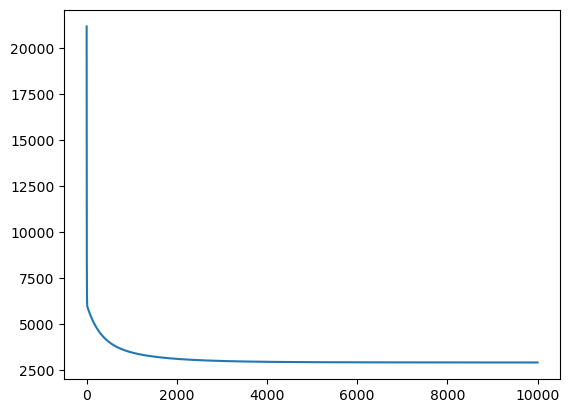

In [61]:
### 7500회 반복 할때쯤 2900아래로 진입하고 10000회에서 2898 변화율이 거의 없습니다. 이정도면 된것 같네요
#matplot 라이브러리로 loss값을 그래프로 시각화 해보겠습니다.
import matplotlib.pyplot as plt

plt.plot(losses)
plt.show()

In [ ]:
# 그래프를 보니 5천회만 해도 충분했을것 같지만 여전히 10000회 결과가 더 좋으니 그대로 사용하겠습니다.

In [45]:
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
mse

np.float64(2880.157326075787)

# 정답데이터와 예측한 데이터를 시각화 해보겠습니다.

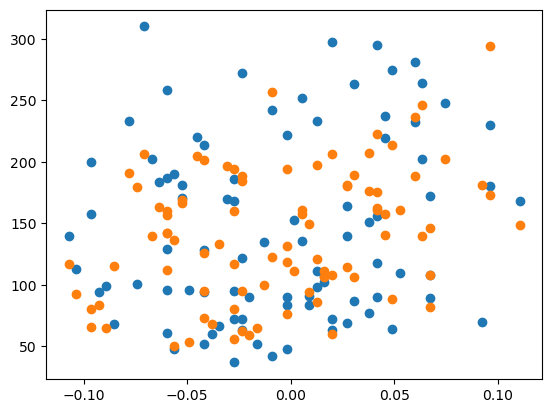

In [62]:


plt.scatter(X_test[:, 0], y_test)
plt.scatter(X_test[:, 0], prediction)
plt.show()

In [64]:
# 분포도가 비슷한걸 확인할수 있습니다. 예측한 결과가 좀더 안쪽으로 군집해있는걸 볼수 있습니다.

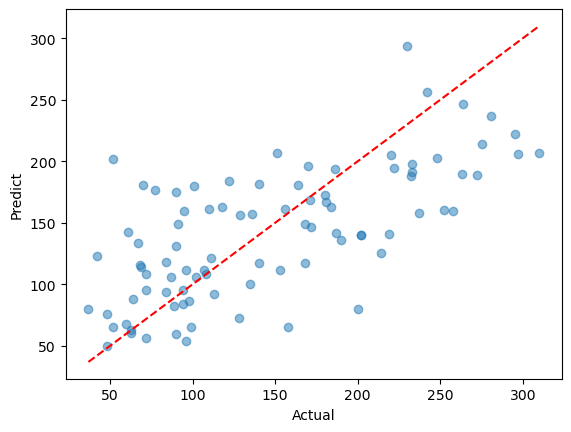

In [67]:
# 추가로 Test : Predict 그래프를 그려보면 다른각도에서 결과를 분석해 볼수 있습니다.

# 점 하나는 환자 한명을 의미하는데, x축에는 정답을, y축예는 예상치를 출력합니다. 
# 따라서 실제 당뇨수치가 예측치와 가까울수록 빨간선과 가깝게 위치하게됩니다.
# 결과를 보면 크게 붙어있지 않지만 어느정도 추세는 맞춘걸 알수 있습니다.
plt.scatter(y_test, prediction, alpha=0.5) 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # 정답선
plt.xlabel('Actual')
plt.ylabel('Predict')
plt.show()

# 프로젝트 2: 날씨 좋은 월요일 오후 세 시, 자전거 타는 사람은 몇 명?

In [5]:
# 캐글 경진대회에서 제공하는 데이터셋에 시간 온도 습도 계절등의 정보가 담겨있는데,
# 이것으로 자전거 대여량을 예측하는 모델을 만들어 봅니다.

In [6]:
import pandas as pd

train = pd.read_csv("~/work/workplace/Data_Analysis/DA01/data/train.csv") 
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [7]:
# datetime 컬럼을 datetime 자료형으로 변환하고 연, 월, 일, 시, 분, 초까지 6가지 컬럼 생성하기
train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

#train['datetime']에 있는 연 월 시 일 분 초 데이터를 별도로 만든 열에 분리해줍니다.

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  minute      10886 non-

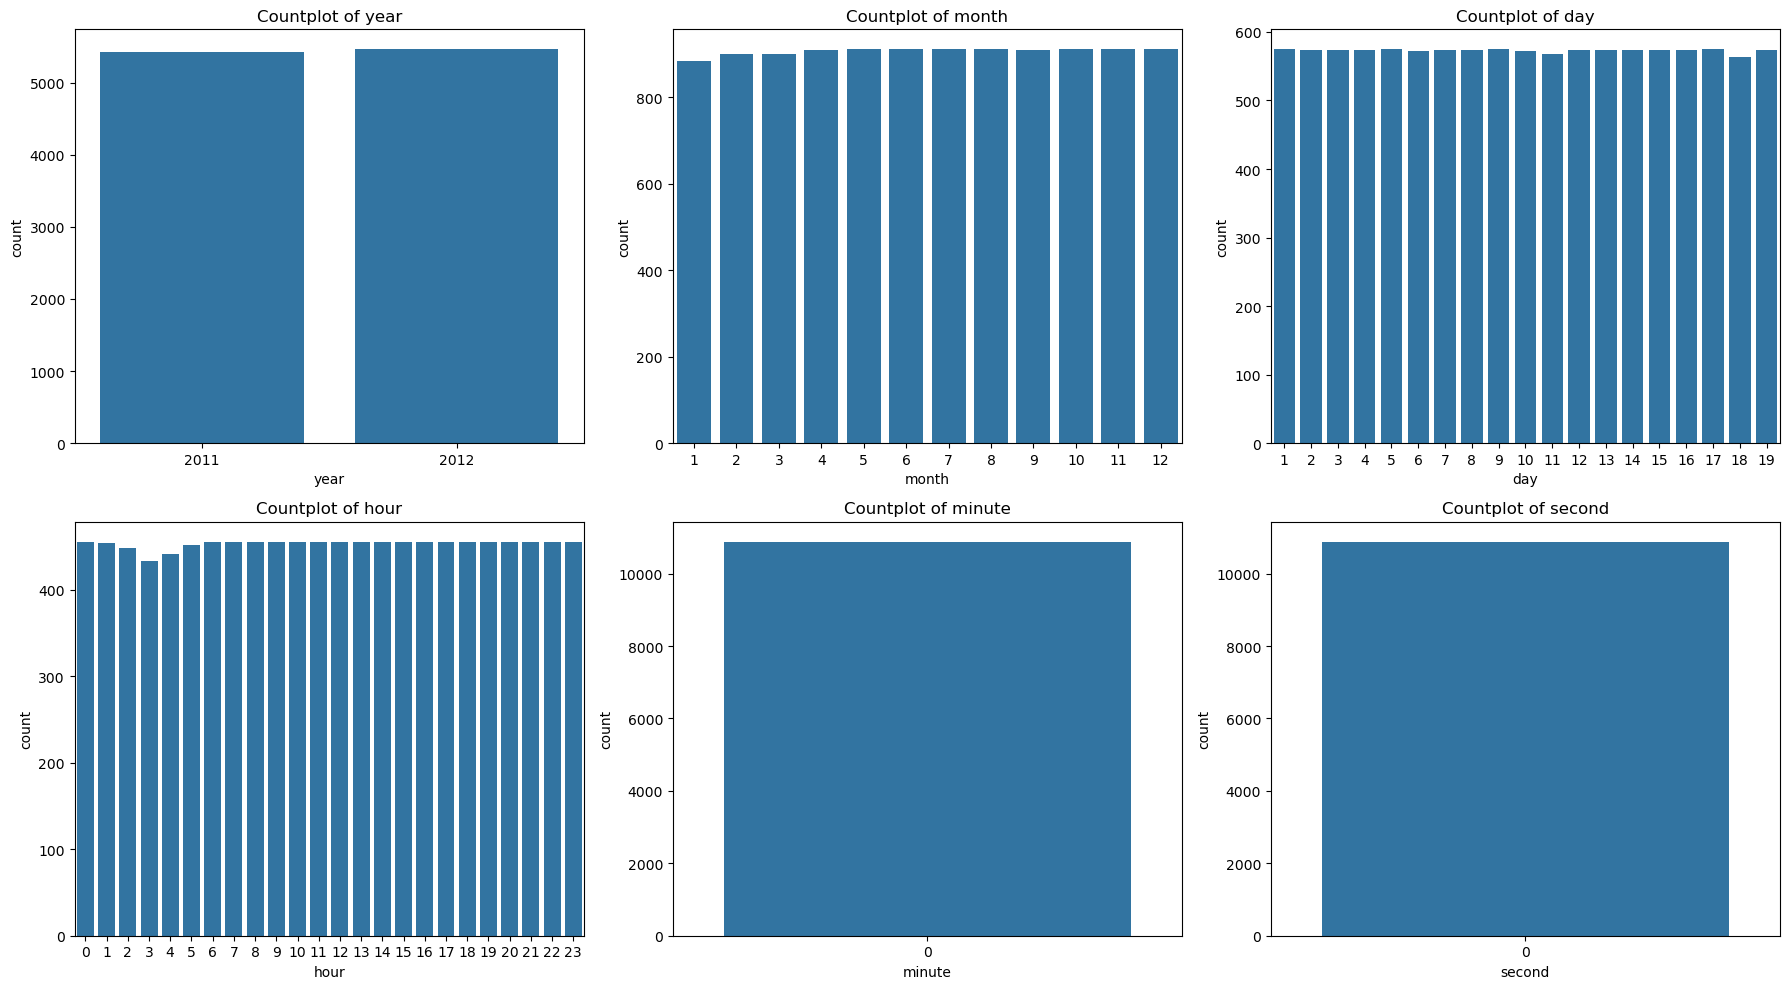

In [8]:
# 아래 int32타입의 6개의 열이 추가로 생긴걸 볼수있습니다.
# year, month, day, hour, minute, second 데이터 개수 시각화하기
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
cols = ['year', 'month', 'day', 'hour', 'minute', 'second']
for ax, col in zip(axs.flatten(), cols):
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(f'Countplot of {col}')
plt.tight_layout()
plt.show()


In [9]:
# minute와 second에는 0값밖에 없는걸보니 datetime 값이 시간까지만 저장된것 같습니다.
# X, y 컬럼 선택 및 train/test 데이터 분리, 시간데이터는 hour까지만 포함하고 분,초는 제외
# 그외에 온도 습도 풍속도 고려사항으로 추가.
features = ['year', 'month', 'day', 'hour', 'temp', 'humidity', 'windspeed']
X = train[features]
y = train['count']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 20%를 테스트 데이터로 분류


In [10]:
#10886개의 데이터 가 8708개 / 2178개의 학습 / 테스트 데이터로 분류됨
print(X, y)
print(X_train.shape, X_test.shape)

       year  month  day  hour   temp  humidity  windspeed
0      2011      1    1     0   9.84        81     0.0000
1      2011      1    1     1   9.02        80     0.0000
2      2011      1    1     2   9.02        80     0.0000
3      2011      1    1     3   9.84        75     0.0000
4      2011      1    1     4   9.84        75     0.0000
...     ...    ...  ...   ...    ...       ...        ...
10881  2012     12   19    19  15.58        50    26.0027
10882  2012     12   19    20  14.76        57    15.0013
10883  2012     12   19    21  13.94        61    15.0013
10884  2012     12   19    22  13.94        61     6.0032
10885  2012     12   19    23  13.12        66     8.9981

[10886 rows x 7 columns] 0         16
1         40
2         32
3         13
4          1
        ... 
10881    336
10882    241
10883    168
10884    129
10885     88
Name: count, Length: 10886, dtype: int64
(8708, 7) (2178, 7)


In [11]:
# 스킷런 라이브러리를 사용해서 선영회귀 모델로 학습
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
# 모델을 사용해서 예측치를 뽑고
# 스킷런 라이브러리로 평균 제곱 오차 측정하고
# 단위를 되돌리기 위해  rmse로 변환
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 19961.901814435438
RMSE: 141.2865946027274


In [13]:
# 그리고 학습률 을 바꿀수있나 알아보았는데 사이킷런은 경사하강법을 쓰지않고 별도의 알고리즘을 사용한다고합니다.
# 대신 SGDRegressor를 사용할경우 경사 하강법을 쓸수 있다고 하네요.
# SGDRegressor을 사용하면 더 오차를 줄일수 있는지 알아봅니다.

from sklearn.linear_model import SGDRegressor
# from sklearn.metrics import mean_squared_error
# import numpy as np

# 1. 모델 객체 생성 (학습률 eta0=0.01 설정)
# learning_rate='constant'는 학습 내내 보폭을 일정하게 유지하라는 뜻입니다.
# invscaling = 학습하면서 보폭을 점점 줄이라는 뜻입니다.
model_sgd = SGDRegressor(max_iter=1000, eta0=0.000001, learning_rate='invscaling', random_state=42)

# 2. 모델 학습
model_sgd.fit(X_train, y_train)

# 3. 예측
y_pred = model_sgd.predict(X_test)

# 4. 성능 평가 
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 22161.63276279501
RMSE: 148.86783656248588


In [14]:
#SGDRegressor을 사용해서 학습율을 조정해보았지만 141보다 더 좋은 수치는 찾기 어려웠습니다.

In [15]:
X_train, y_train

(      year  month  day  hour   temp  humidity  windspeed
 2815  2011      7    6     5  27.88        83     6.0032
 8695  2012      8    4    16  36.90        39    19.9995
 8406  2012      7   11    15  32.80        41    16.9979
 1543  2011      4   10     4  14.76        93     7.0015
 4952  2011     11   19    10  13.12        45    16.9979
 ...    ...    ...  ...   ...    ...       ...        ...
 5734  2012      1   14     2   6.56        47    11.0014
 5191  2011     12   10     9  11.48        61    19.0012
 5390  2011     12   18    16  11.48        48    16.9979
 860   2011      2   19     7  15.58        17    35.0008
 7270  2012      5    2     7  22.14        88    12.9980
 
 [8708 rows x 7 columns],
 2815     35
 8695    450
 8406    276
 1543      5
 4952    200
        ... 
 5734     38
 5191    149
 5390    234
 860      22
 7270    358
 Name: count, Length: 8708, dtype: int64)

# 모델의 성능을 높이기 위해 데이터 전처리

학습율을 조정하다보니 느꼈는데 학습율값은 데이터 크기에 민감하다고 배웠는데,
우리 데이터를 다시 살펴보니 데이터 크기가 중구난방입니다 Normalization이 필요하다고 생각이 듭니다.
또한, year값이 2011,2012 밖에 없습니다. 이후 예측할 데이터가 2011이나 2012라면 도움이 될지도 모르겠으나, 

1. 2020이나 2100처럼 크게 다른 데이터가 들어오면 오히려 데이터가 튀어서 오히려 방해요소가 될수도 있다는 생각이 들어서
2. year값은 제외 하도록 합니다. 먼저 year을 제외하고 나머지 데이터를 normalization 하겠습니다.
3. day값도 이게 월화수목금토일 을 구분하는거면 도움이 될수있을지 모르겠지만, 단순히  1일~31일을 구분해서는
   모델이 판단하는데 아무 도움이 안될것 같아서 제외하겠습니다.
4. month는 계절에 영향이 크고, hour도 새벽에 자전거타는사람은 거의없으니 중요한 요소같아요 그리고 주제 자체가
   오후 3시에 자전거 타는사람을 찾는거니 필수로 갖고있어야 겠죠.
5. 마지막으로 day대신 월화수..토일 요일을 넣어주면 도움이 될거같아요 주말에는 자전거 타는사람이 더 많으니까요

In [16]:
# holiday 컬럼 확인 (0: 평일/주말, 1: 공휴일)
print("--- Holiday Count ---")
print(train['holiday'].value_counts())

# workingday 컬럼 확인 (0: 휴일, 1: 평일)
print("\n--- Workingday Count ---")
print(train['workingday'].value_counts())

# weather 컬럼 확인 (1: 맑음 ~ 4: 아주 안 좋음)
print("\n--- Weather Count ---")
print(train['weather'].value_counts())

--- Holiday Count ---
holiday
0    10575
1      311
Name: count, dtype: int64

--- Workingday Count ---
workingday
1    7412
0    3474
Name: count, dtype: int64

--- Weather Count ---
weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64


In [17]:
# 공휴일, 주말/평일, 날씨 정보가 기본 테이블에 있는걸 확인해서 이들도 이용해보도록 하겠습니다

In [18]:
features = ['month', 'hour', 'holiday', 'workingday', 'weather', 'temp', 'humidity', 'windspeed']
X = train[features]
y = train['count']

# 1. 먼저 판다스를 dummies를 사용해서 원-핫 범주 카테고리 3개에 인코딩 적용
X_encoded = pd.get_dummies(X, columns=['holiday', 'workingday', 'weather'])
X_encoded


,month,hour,temp,humidity,windspeed,holiday_0,holiday_1,workingday_0,workingday_1,weather_1,weather_2,weather_3,weather_4
0,1,0,9.84,81,0.0000,True,False,True,False,True,False,False,False
1,1,1,9.02,80,0.0000,True,False,True,False,True,False,False,False
2,1,2,9.02,80,0.0000,True,False,True,False,True,False,False,False
3,1,3,9.84,75,0.0000,True,False,True,False,True,False,False,False
4,1,4,9.84,75,0.0000,True,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,12,19,15.58,50,26.0027,True,False,False,True,True,False,False,False
10882,12,20,14.76,57,15.0013,True,False,False,True,True,False,False,False
10883,12,21,13.94,61,15.0013,True,False,False,True,True,False,False,False
10884,12,22,13.94,61,6.0032,True,False,False,True,True,False,False,False


In [19]:
# 2. 표준화 하기전에 데이터 분할부터 해주겠습니다
# 정규화대신 표준화를 선택한 이유는, 값 차이가 큰 year값은 제거했지만 여전히 작은값은 0~4 이고 큰값은 80이 넘습니다
# 데이터 단위차이가 크므로 표준화가 적합해보입니다.
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [20]:
# 3. Standardization 표준화 
from sklearn.preprocessing import OneHotEncoder, StandardScaler

scaler = StandardScaler()

# 학습데이터 변환 - 학습후 변환하는 fit_transfrom 함수사용
X_train_scaled = scaler.fit_transform(X_train)
#예측용 테스트데이터 변환
X_test_scaled = scaler.transform(X_test)

print("정규화 완료된 데이터 샘플:\n", X_train_scaled[0])

정규화 완료된 데이터 샘플:
 [ 0.13822447 -0.94596221  0.97726179  1.09855333 -0.82835619  0.17333479
 -0.17333479 -0.68444534  0.68444534  0.71357231 -0.58990475 -0.29312273
 -0.01071681]


In [21]:
#이전에 임포트한 선영회귀모델을 다시 사용합니다.
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
# 다시 오차값을 측정해봅니다 이전에 선형회귀를 사용했을때 값 RMSE=19961, MSE=141
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 21586.191552303328
RMSE: 146.92239976362805


In [23]:
# 이런! 오히려 값이 안좋아졌군요.

# 다시 위에서 시도해봤던 경사 하강법을 사용해보겠습니다.
model_sgd = SGDRegressor(max_iter=1000, eta0=0.000001, learning_rate='invscaling', random_state=42)

# 2. 모델 학습
model_sgd.fit(X_train, y_train)

# 3. 예측
y_pred = model_sgd.predict(X_test)

# 4. 성능 평가 
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 21745.691687651644
RMSE: 147.46420476729816


In [24]:
# 학습율 값을 수정 1
model_sgd = SGDRegressor(max_iter=1000, eta0=0.00001, learning_rate='invscaling', random_state=42)

# 2. 모델 학습
model_sgd.fit(X_train, y_train)

# 3. 예측
y_pred = model_sgd.predict(X_test)

# 4. 성능 평가 
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 21769.046315535074
RMSE: 147.5433709643882


In [25]:
# 학습율 값을 수정 2
model_sgd = SGDRegressor(max_iter=1000, eta0=0.0001, learning_rate='invscaling', random_state=42)

# 2. 모델 학습
model_sgd.fit(X_train, y_train)

# 3. 예측
y_pred_sgd = model_sgd.predict(X_test)

# 4. 성능 평가 
mse_sgd = mean_squared_error(y_test, y_pred)
rmse_sgd = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 21769.046315535074
RMSE: 147.5433709643882


In [26]:
# 학습율 값을 수정 3
model_sgd = SGDRegressor(max_iter=10000, eta0=0.000001, learning_rate='invscaling', random_state=42)

# 2. 모델 학습
model_sgd.fit(X_train, y_train)

# 3. 예측
y_pred_sgd = model_sgd.predict(X_test)

# 4. 성능 평가 
mse = mean_squared_error(y_test, y_pred_sgd)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 21745.691687651644
RMSE: 147.46420476729816


In [27]:
# 왜 선형회귀나, 경사하강법으로 안좋은결과가 나올까 고민이들어서 검색해보니
# 이 두종류 모델은 데이터 관계가 직선형일때 잘작동한다는 한계가 있다고 하네요.
# 이번 문제같은 온도 습도 시간등 여러 복잡한 데이터가 있는경우, 실제 비선형모델이 좋다고 합니다.
# 결정트리 기반의 랜덤포레스트 모델을 사용해 보겠습니다.

from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 2. 모델 학습
model_rf.fit(X_train_scaled, y_train)

# 3. 예측
y_pred_rf = model_rf.predict(X_test_scaled)

# 4. 성능 평가
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print("MSE:", mse_rf)
print("RMSE:", rmse_rf)

MSE: 4699.904217104828
RMSE: 68.55584743189182


In [28]:
# RMSE 값이 획기적으로 줄어든걸 알수 있습니다. 다른모델도 있지만, 
# 단순히 모델을 교체하고 오차 줄어드는것만 확인하는건 도움이 될거같지않아 
# 세 가지 모델을 사용해본것으로 만족하겠습니다.

# 현재까지 데이터


1. Scikit-Learn 선형회귀 (전처리 전)       RMSE=19961, MSE=141
2. Scikit-Learn 선형회귀                  RMSE=22161, MSE=148
3. SGDRegressor (경사하강법)               RMSE=21745, MSE=147
4. RandomForest (랜덤포레스트)              RMSE=4699, MSE=68

###### 주의깊게 봐야 할 부분은 같은 선형회귀모델을 사용했을때, 주말, 계절, 날씨 등을 추가한 데이터를 가진 전처리 후의 오차가 더 큰걸 알수있습니다.
###### 데이터가 다양해지면서 오히려 복잡도가증가하여 선형모델에게 불리해진것으로 짐작해봅니다.

###### 비선형모델인 랜덤포레스트에서는 오차가 드라마틱하게 줄어든걸 볼수있습니다.

# 예측 결과 시각화 (선형>SGD>랜덤포레스트)

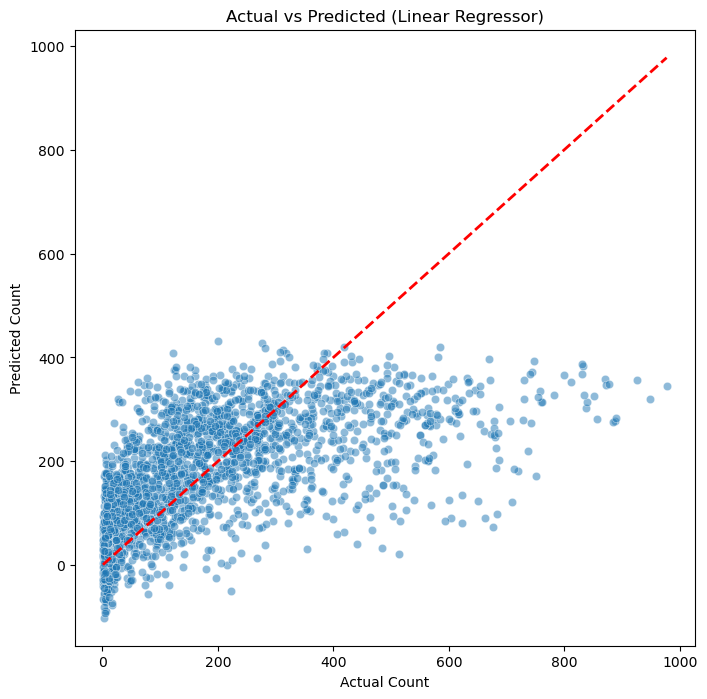

In [29]:
#선형회귀모델 예측결과 시각화
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5) # 실제값과 예측값 시각화
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # 45도 기준선

plt.xlabel('Actual Count')
plt.ylabel('Predicted Count')
plt.title('Actual vs Predicted (Linear Regressor)')
plt.show()

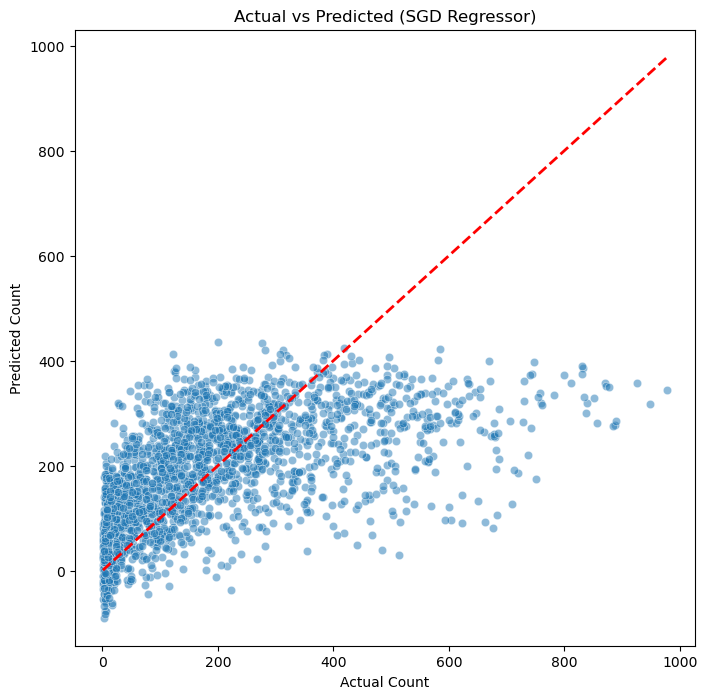

In [30]:
# SGD 경사하강법 결과 시각화
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred_sgd, alpha=0.5) # 실제값과 예측값 시각화
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # 45도 기준선

plt.xlabel('Actual Count')
plt.ylabel('Predicted Count')
plt.title('Actual vs Predicted (SGD Regressor)')
plt.show()

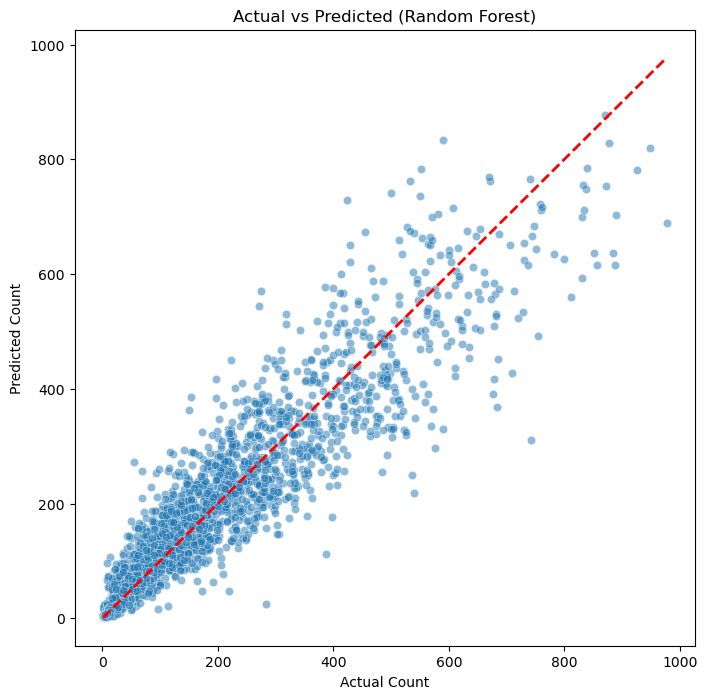

In [31]:
#랜덤 포레스트 예측 결과 시각화
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5) # 실제값과 예측값 시각화
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # 45도 기준선

plt.xlabel('Actual Count')
plt.ylabel('Predicted Count')
plt.title('Actual vs Predicted (Random Forest)')
plt.show()

# 3개 모델의 예측 결과 비교 시각화

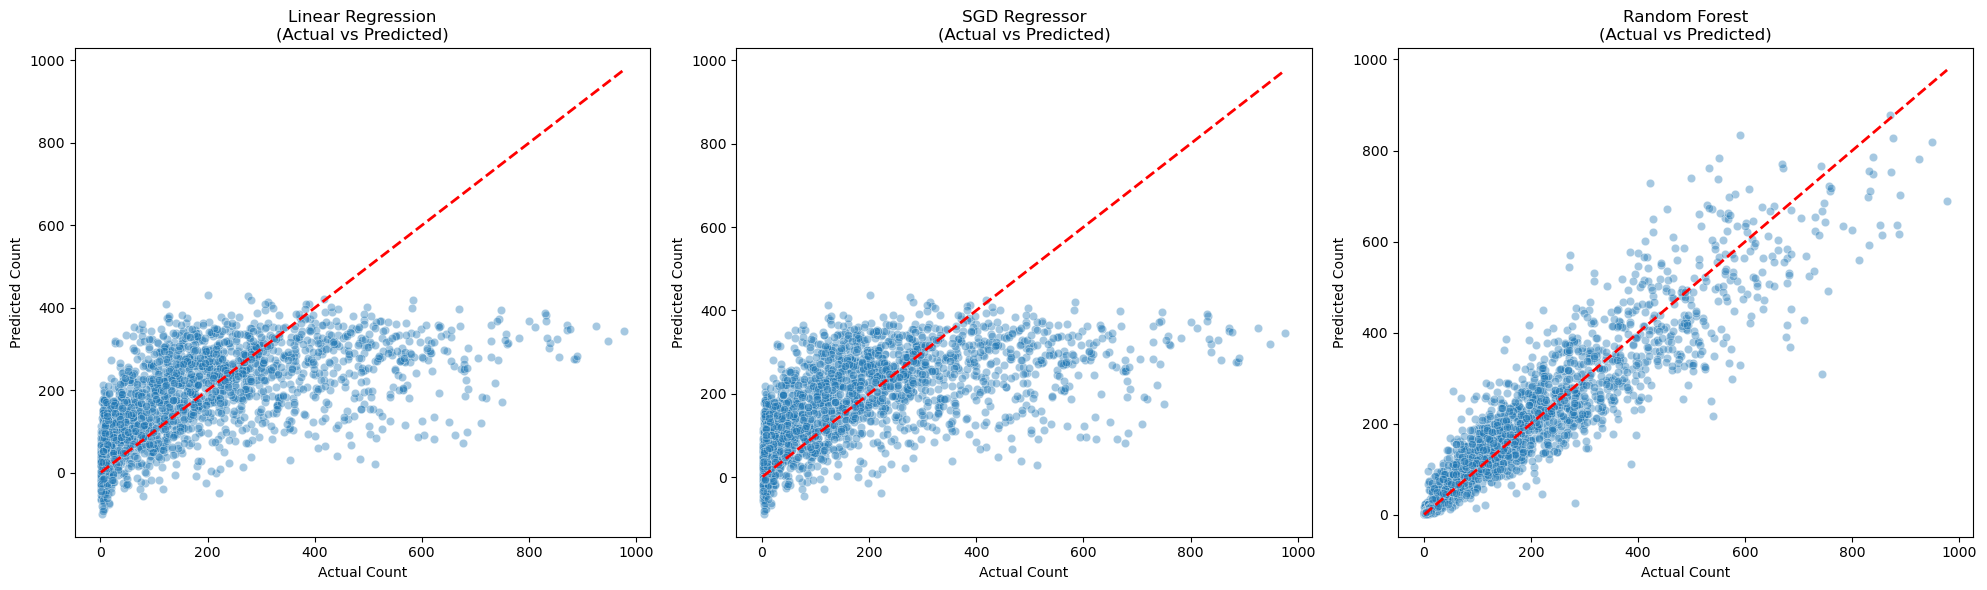

In [32]:
# 3개 그래프를 한번에 띄우기
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
models = ['Linear Regression', 'SGD Regressor', 'Random Forest']
preds = [y_pred, y_pred_sgd, y_pred_rf]

for i, (name, pred) in enumerate(zip(models, preds)):
    sns.scatterplot(x=y_test, y=pred, ax=axes[i], alpha=0.4)
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[i].set_title(f'{name}\n(Actual vs Predicted)')
    axes[i].set_xlabel('Actual Count')
    axes[i].set_ylabel('Predicted Count')

plt.tight_layout()
plt.show()

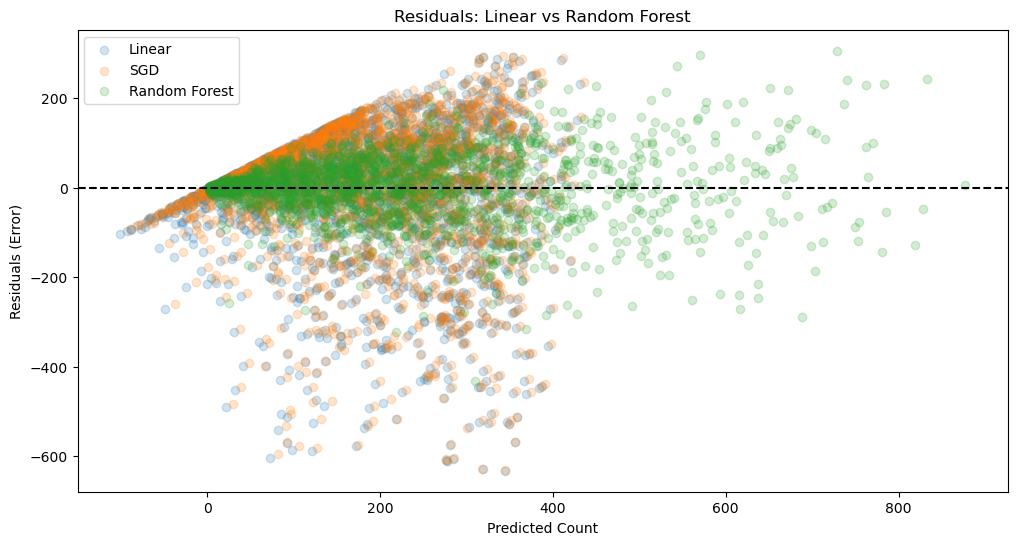

In [33]:
# 얼마나 맞췄는지가 아닌 얼마나 틀렸는지 비교하는 잔차도 그래프
plt.figure(figsize=(12, 6))
plt.scatter(y_pred, y_pred - y_test, alpha=0.2, label='Linear')
plt.scatter(y_pred_sgd, y_pred_sgd - y_test, alpha=0.2, label='SGD')
plt.scatter(y_pred_rf, y_pred_rf - y_test, alpha=0.2, label='Random Forest')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residuals: Linear vs Random Forest')
plt.xlabel('Predicted Count')
plt.ylabel('Residuals (Error)')
plt.legend()
plt.show()

In [34]:
# 예측 결과가 Zero Line에  가까울수록 잘맞춘거고 퍼질수록 오답이 큰것입니다. 
# 확실히 RMSE 수치대로 Random Forest모델이 저 선에 가깝게 모여있는것을 알수 있습니다.

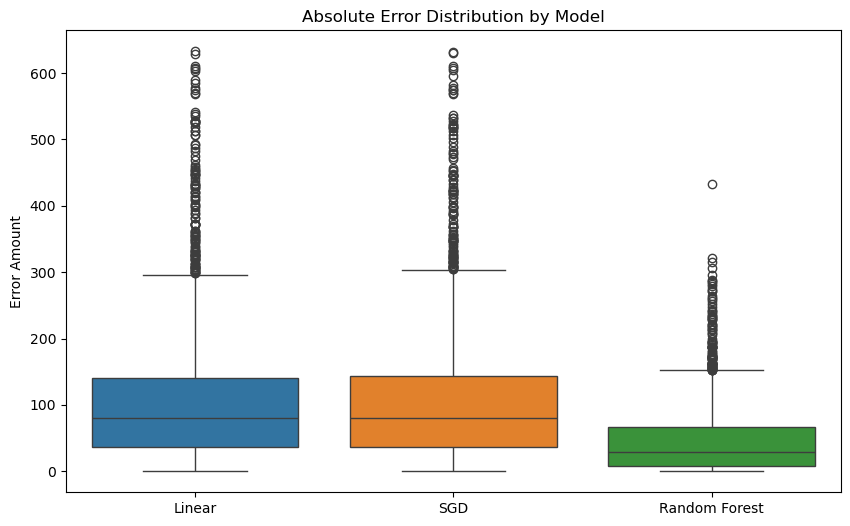

In [35]:
errors = pd.DataFrame({
    'Linear': np.abs(y_test - y_pred),
    'SGD': np.abs(y_test - y_pred_sgd),
    'Random Forest': np.abs(y_test - y_pred_rf)
})

plt.figure(figsize=(10, 6))
sns.boxplot(data=errors)
plt.title('Absolute Error Distribution by Model')
plt.ylabel('Error Amount')
plt.show()

In [36]:
# 오차 박스그래프는 박스가 아래에 위치할수록 평균적으로 잘 맞추는것입니다.
# 박스 위 아래에 멀리보이는 점들은 이상치가 얼마나 많고 얼마나 넓게 분포되어있는지
# 가늠하는데 도움이 됩니다. 수염(Whiskers)라는 용어를 쓴다고 하네요.

# 랜덤 포레스트 모델조차 수염이 160~300 사이에 많이 분포되어있고, 450정도에도 하나가 보이는데
# 이는 이상치가 꽤많이 존재해서 아주 정확하게 맞출수있는 모델까지는 되지못했다는걸 증명합니다.
# 실제 상용서비스로 쓰려면 높은 정확도, 높은 재현율이 중요하겠죠.

# 온도 습도에 대한 예측결과 시각화

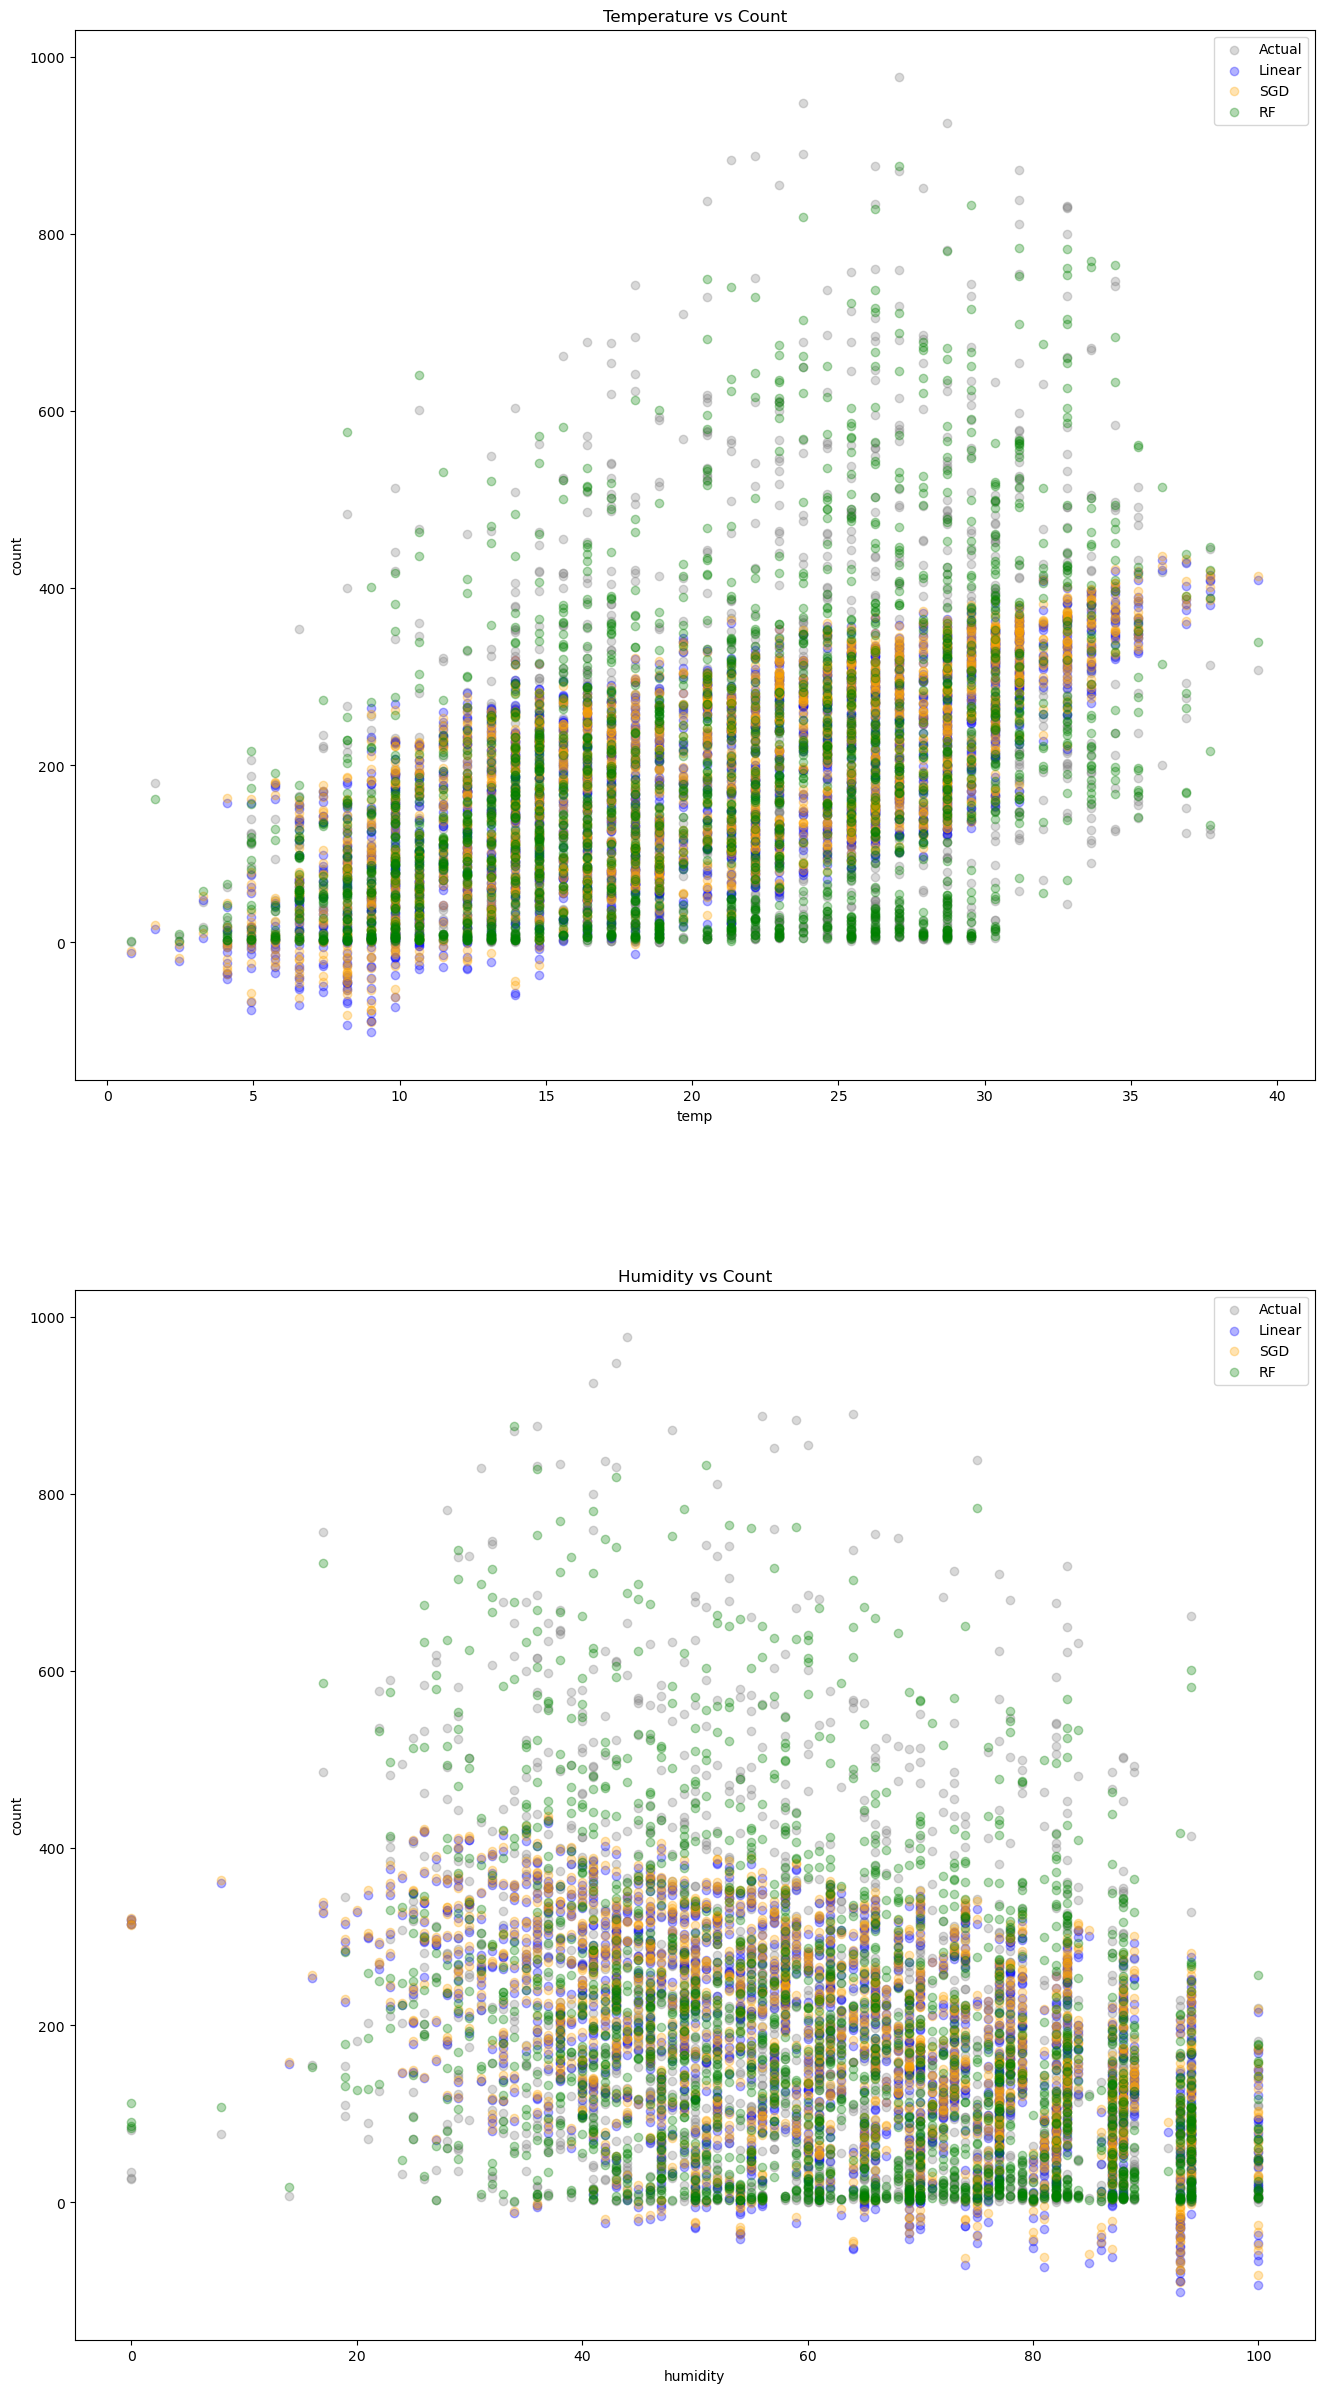

In [37]:
fig, axs = plt.subplots(2, 1, figsize=(16, 30))

# temp vs count 시각화
axs[0].scatter(X_test['temp'], y_test, color='grey', label='Actual', alpha=0.3)
axs[0].scatter(X_test['temp'], y_pred, color='blue', label='Linear', alpha=0.3)
axs[0].scatter(X_test['temp'], y_pred_sgd, color='orange', label='SGD', alpha=0.3)
axs[0].scatter(X_test['temp'], y_pred_rf, color='green', label='RF', alpha=0.3)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# humidity vs count 시각화
axs[1].scatter(X_test['humidity'], y_test, color='grey', label='Actual', alpha=0.3)
axs[1].scatter(X_test['humidity'], y_pred, color='blue', label='Linear', alpha=0.3)
axs[1].scatter(X_test['humidity'], y_pred_sgd, color='orange', label='SGD', alpha=0.3)
axs[1].scatter(X_test['humidity'], y_pred_rf, color='green', label='RF', alpha=0.3)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()



In [ ]:
# 두 가지모델을 한곳에 띄워서 알아보기 힘든데요.
# 눈에 띄는점은 실제 결과가 집중적으로 분포된부분은 선형모델들이 잘예측을 하지만 
# 작게 분포 (그래프에서 상단부분) 에서는 실제결과 (회색) 과 RF모델의 예측결과(녹색) 말고는 찾아보기 힘듭니다.
# 선형모델인 파란색과 SGD모델인 주황색은 거의 안보이죠.

# 프로젝트 결론을 위해 날씨 좋은 월요일 오후 3시 자전거 타는사람이 몇명인지 알아봅시다
# 먼저 예측할 테스트 데이터를 만들어야 하니까 현재 존재하는 데이터가 어떻게 되어있는지 봅시다.

In [39]:
X_test.loc[0]

month               1
hour                0
temp             9.84
humidity           81
windspeed         0.0
holiday_0        True
holiday_1       False
workingday_0     True
workingday_1    False
weather_1        True
weather_2       False
weather_3       False
weather_4       False
Name: 0, dtype: object

In [40]:
# 저는 약간 이상한 점을 발견했는데 1월의 어느날인데 공휴일도 아니고, 일하는날도 아니라고합니다.
# 주말은 holiday에 포함이 되지않은걸까요?
# 현실에서는 주말을 holiday로 치지는 않지만 이데이터에서는 왠지 주말도 holiday에 포함시키지 않을까 싶었는데
# 확인해보죠

# holiday가 1인 데이터만 필터링하여 상위 20개 출력
holiday_data_20 = train[train['holiday'] == 1].head(20)

print(holiday_data_20)

               datetime  season  holiday  workingday  weather  temp   atemp  \
372 2011-01-17 00:00:00       1        1           0        2  8.20   9.850   
373 2011-01-17 01:00:00       1        1           0        2  8.20   9.850   
374 2011-01-17 02:00:00       1        1           0        2  7.38   8.335   
375 2011-01-17 03:00:00       1        1           0        2  7.38   9.090   
376 2011-01-17 04:00:00       1        1           0        2  7.38   9.850   
377 2011-01-17 05:00:00       1        1           0        2  7.38   9.850   
378 2011-01-17 06:00:00       1        1           0        2  7.38   9.090   
379 2011-01-17 07:00:00       1        1           0        2  6.56   9.090   
380 2011-01-17 08:00:00       1        1           0        2  6.56   7.575   
381 2011-01-17 09:00:00       1        1           0        2  6.56   7.575   
382 2011-01-17 10:00:00       1        1           0        2  6.56   7.575   
383 2011-01-17 11:00:00       1        1           0

In [41]:
# 데이터가 많아서 1월 17일만 나오는군요.  1월 17일은은 미국의 마틴 루터 킹 주니어 탄생일로 연방공휴일이라고 하네요
# 데이터 출처가 미국인것을 알수있습니다.
# 좀더 확실히 하기위해 더블체크해보겠습니다. 다음 공휴일도 찾아보죠

holiday_data_20 = train[train['holiday'] == 1].head(26)

print(holiday_data_20)

                datetime  season  holiday  workingday  weather   temp   atemp  \
372  2011-01-17 00:00:00       1        1           0        2   8.20   9.850   
373  2011-01-17 01:00:00       1        1           0        2   8.20   9.850   
374  2011-01-17 02:00:00       1        1           0        2   7.38   8.335   
375  2011-01-17 03:00:00       1        1           0        2   7.38   9.090   
376  2011-01-17 04:00:00       1        1           0        2   7.38   9.850   
377  2011-01-17 05:00:00       1        1           0        2   7.38   9.850   
378  2011-01-17 06:00:00       1        1           0        2   7.38   9.090   
379  2011-01-17 07:00:00       1        1           0        2   6.56   9.090   
380  2011-01-17 08:00:00       1        1           0        2   6.56   7.575   
381  2011-01-17 09:00:00       1        1           0        2   6.56   7.575   
382  2011-01-17 10:00:00       1        1           0        2   6.56   7.575   
383  2011-01-17 11:00:00    

In [ ]:
# 데이터는 시간순으로 되어있는데 다음공휴일은 4월 15일 이군요
# 일반적인 경우가 아니라 검색을 여러번 했어야했는데
# 미국의 워싱턴 DC에서만 4월 15일이 공휴일이었다는군요
# 노예해방 기념일로 4월 16일이 공휴일인데 이날이 토요일이라 
# 4월 15일이 대체공휴일로 지정되었다는군요
# 따라서 이 데이터 출처는 미국의 워싱턴 DC라는것을 추측 해 볼 수있습니다.
# 당장은 필요없어보이지만 나중에 모델 개선에 필요할수있으니 노트를 해둘 필요는 있어보입니다.
# 모델을 더 개선할 방법이 생겼네요. 바로 주말 카테고리를 추가하는겁니다.

In [44]:
# 주말 카테고리 추가하기

# 먼저 datetime 에서 weekend정보를 빼내는 방법을 고민해보죠
# 위에서 사용한 데이터를 재사용해서 1월 17일과 4월 15일의 weekday값을 확인해봅니다.
train[train['holiday'] == 1]['datetime'].head(26).dt.weekday


372     0
373     0
374     0
375     0
376     0
377     0
378     0
379     0
380     0
381     0
382     0
383     0
384     0
385     0
386     0
387     0
388     0
389     0
390     0
391     0
392     0
393     0
394     0
395     0
1658    4
1659    4
Name: datetime, dtype: int32

In [46]:
# 1월 17일은 월요일인데 값이 0
# 4월 14일은 금요일인데 값이 4
# 제대로 확인이 되는걸 확인했으니 weekday라는 새로운 열을 추가해줍니다.
# 바로 weekend를 추가해줄수도 있지만 나중에 weekday값이 필요해질수도있으니 만들어 두겠습니다.
train['weekday'] = train['datetime'].dt.weekday
# 5=토요일 or 6=일요일 인경우 weekend에 1이 들어가도록 합니다.
train['weekend'] = (train['weekday'] >= 5).astype(int)


In [47]:
#날짜가 바뀔때마다 하나씩 출력되도록 필터를 걸어줍니다.
day_changed = train['day'] != train['day'].shift()
changed_rows = train[day_changed].head(20)

print(changed_rows)

               datetime  season  holiday  workingday  weather   temp   atemp  \
0   2011-01-01 00:00:00       1        0           0        1   9.84  14.395   
24  2011-01-02 00:00:00       1        0           0        2  18.86  22.725   
47  2011-01-03 00:00:00       1        0           1        1   9.02   9.850   
69  2011-01-04 00:00:00       1        0           1        1   6.56   9.090   
92  2011-01-05 00:00:00       1        0           1        1   8.20  12.880   
115 2011-01-06 00:00:00       1        0           1        1   7.38  12.120   
138 2011-01-07 00:00:00       1        0           1        2   8.20   9.850   
161 2011-01-08 00:00:00       1        0           0        2   7.38   9.850   
185 2011-01-09 00:00:00       1        0           0        1   4.10   3.790   
209 2011-01-10 00:00:00       1        0           1        1   4.92   6.060   
233 2011-01-11 00:00:00       1        0           1        1   5.74   8.335   
255 2011-01-12 00:00:00       1        0

In [49]:
# 먼저 데이터검증을 해보겠습니다 잘 추가되었다면 holiday이거나 weekend 둘중 하나라도 1이면 workingday는 0 이어야합니다.
condition = ((train['holiday'] == 1) | (train['weekend'] == 1)) & (train['workingday'] == 1)

result = train[condition]

len(result)

# 0으로 문제가 없는것 같습니다.

0

In [57]:
# 데이터를 추가하는도중 몇가지 새로운 사실을 알았습니다.
# 날짜별로 데이터가 존재하긴하지만 모든데이터가 존재하는건 아니다.
# 1월 20일부터 31일까지 데이터는 없는걸 알수있고.
# 1월 18일도 오전 0시부터 11시까지의 데이터가 없는걸 알수있습니다.
# 실제 데이터를 기반으로 하다보니 결측치가 상당히 있는걸 알수있습니다.
# 우리는 여기서 15년전 미국의 워싱턴DC의 실제데이터를 임의로 넣어줄수 없는 사실을 잘 알고있습니다.
# 따라서 무시하고 지나갈수밖에 없는데 여기서 우리는 2가지를 판단 할 수 있습니다.
# 1. 이 데이터셋으로 월별통계를 내서 예측을하면 오류가 심해질수있다.
# 2. 그만큼 날짜 하나하나마다의 요일이나 주말 공휴일 여부 날씨여부가 중요해진다.

#아무튼 weekday와 weekend까지 모두 잘 입력된걸 알수 있습니다.

# 두번째로 추가하고싶은데이터는 몇일 연속으로 쉬는날인지에 대한 데이터입니다.
# 사람들은 공휴일이 주말하고 연계되서 3일이상 쉬게될경우에 집에서 쉬기보다 
# 뭔가 액티비티활동을 하게되는 경향이 크다고 생각합니다.
# 따라서 1일이 토요일 2일이 일요일 인데 3일이 공휴일이라면 이 1~3일 데이터에 이 날은 3일 연속 쉬는날중 하루라는 열을 추가해주려합니다.

# 1. 재정렬 이미 데이터가 정렬되어있는걸 알지만 직접 일일히 확인해보지않아서 직접 다시정렬합니다.
train = train.sort_values('datetime').reset_index(drop=True)

# 2. 쉬는 날 추가
train['is_nowork'] = ((train['weekend'] == 1) | (train['holiday'] == 1))

# 3. 날짜정보만 추출 (위에서 시간정보가 없는걸 확인했지만 1번과 같은이유로 새로운 열을 만들어줍니다)
train['date_only'] = pd.to_datetime(train['datetime'].dt.date)

# 4. 그룹화 처리 (수정됨)
# 이전 행과 날짜가 1일 넘게 차이 나는지 체크

# 조건 1: 휴일 여부가 바뀌었을 때
cond1 = (train['is_nowork'] != train['is_nowork'].shift())

# 조건 2: 날짜가 연속적이지 않을 때 (오늘 날짜와 어제 날짜의 차이가 1일보다 클 때)
# 단, 같은 날짜 내의 시간 데이터(0시, 1시...)는 날짜 차이가 0이므로 무시됩니다.
date_diff = train['date_only'].diff().dt.days
cond2 = (date_diff > 1)

# 그룹 번호 생성
group_key = (cond1 | cond2).cumsum()

# 5. 그룹별 연속 일수 계산 (더 효율적인 방식)
# transform을 사용하면 원래 index를 유지하며 결과가 뿌려집니다.
train['consecutive_nowork_days'] = train.groupby(group_key)['date_only'].transform('nunique')

# 6. 평일(is_nowork == False)인 행은 값을 0으로 밀어버림 (마무리)
train.loc[~train['is_nowork'], 'consecutive_nowork_days'] = 0

print(train[['datetime', 'is_nowork', 'consecutive_nowork_days']].iloc[40:81])


              datetime  is_nowork  consecutive_nowork_days
40 2011-01-02 17:00:00       True                        2
41 2011-01-02 18:00:00       True                        2
42 2011-01-02 19:00:00       True                        2
43 2011-01-02 20:00:00       True                        2
44 2011-01-02 21:00:00       True                        2
45 2011-01-02 22:00:00       True                        2
46 2011-01-02 23:00:00       True                        2
47 2011-01-03 00:00:00      False                        0
48 2011-01-03 01:00:00      False                        0
49 2011-01-03 04:00:00      False                        0
50 2011-01-03 05:00:00      False                        0
51 2011-01-03 06:00:00      False                        0
52 2011-01-03 07:00:00      False                        0
53 2011-01-03 08:00:00      False                        0
54 2011-01-03 09:00:00      False                        0
55 2011-01-03 10:00:00      False                       

In [64]:
# 위에 데이터를 보면 1월1일~1월2일은 토,일로 연속2일쉬는날로 잘 출력이되고있습니다.
# 추가가 잘 된 것같군요. 3일이상 연속 쉬는날도 체크해볼게요
train[train['consecutive_nowork_days'] >= 3]['consecutive_nowork_days'].value_counts()

#총 792개의 데이터 즉 (24 * 3) 으로 나누면 전체 데이터중에 3일이상 쉬는날이 11번 있었음을 알수있습니다.
#결측치가 있는걸 알고는 있지만 24로떨어지는것보니 11일이 맞을것 같습니다 중요한건 아니니 패스.
#그리고 4일이상 연속휴일이 없었다는것도 알수있네요

consecutive_nowork_days
3    792
Name: count, dtype: int64

In [73]:

# 사용할 데이터에 weekday와 weekend를 추가해주고 year과 day는 여전히 제외시키겠습니다.

# 근데 이번에는 데이터 셋을 3개 준비해보려고합니다. 한번 실행하고 스크롤 올려서 확인하고
# 이러는것보다 비교하면서 진행하는게 좋을것 같습니다.

# 저는 아래처럼 4개의 데이터셋으로 나누겠습니다
# (1) ALL: 지금까지한것중 불필요하다고 여겨지는거 빼고 모두 포함
# (2) less_holiday: consecutive_nowork_days는 holiday, workingday와 매우 관련이
#                   깊습니다 데이터가 너무많아서 오히려 안좋은 결과가 나올수 있을것 같아요
# (3) less_weather: 여기선 날씨관련 정보를 제외하고 예측해볼게요 온습도,풍속,날씨 제외
# (4) lesser:       과감하게  (2), (3) 에서 제거한것을 모두 제거합니다

# 데이터셋을 이렇게 준비한데에는 이유가있습니다. 위에 말했듯 연속해서 2일,3일 쉬는것이 중요한 요소라고 생각함.
# 그래도 날씨가 너무 안좋으면 확실히 타는사람이 줄어들것이라고 생각함 
# 주말인지 holiday인지는 중요하지않고 쉬는날인지 아닌지 그리고 몇일 연속으로 쉴수있는지를 더 중요하게생각
# 그리고 마지막으로 혹시모르니까 그냥 최대한가볍게 내가 제일 중요하다고 생각하는 요소만 넣고 해보자, 
# 애초에 month도 계절을 대신한다고 생각하고 넣은거니 빼줄게요

# 그리고 조심스럽게 2번 데이터셋으로 훈련한 모델이 가장 효과가 좋을것이라 예측도 해봅니다. 과연 맞출수 있을지?

# 중요하다고 생각한 factors 연속휴일수 > 날씨 > 주말,공휴일 여부 

# 변수명은 그냥 뒤에 1,2,3,4 숫자를 붙일게요 너무 길어지니까.
features1 = ['month', 'hour', 'holiday', 'workingday', 'weather', 'temp', 'humidity', 'windspeed', 'weekday', 'weekend', 'consecutive_nowork_days']
features2 = ['month', 'hour', 'weather', 'temp', 'humidity', 'windspeed', 'consecutive_nowork_days']
features3 = ['month', 'hour', 'holiday', 'workingday', 'weekday', 'weekend', 'consecutive_nowork_days']
features4 = ['hour', 'consecutive_nowork_days']

X = train[features1]
y = train['count']

# padas로 원핫인코딩
# consecutive_nowork_days 를 원핫인코딩을 할때랑 안할때랑 다를것같지만 너무 테스트데이터가 많아지니까 제외
# 아래에서 standardizatin만 해줄게요
X_encoded = pd.get_dummies(X, columns=['holiday', 'workingday', 'weather', 'weekday', 'weekend'])

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)


In [96]:
# 3. Standardization 표준화 
# from sklearn.preprocessing import OneHotEncoder, StandardScaler # 위에서 했음

scaler = StandardScaler()

# 학습데이터 변환 - 학습후 변환하는 fit_transfrom 함수사용
X_train_scaled = scaler.fit_transform(X_train)
#예측용 테스트데이터 변환
X_test_scaled = scaler.transform(X_test)

print("정규화 완료된 데이터 샘플:\n", X_train_scaled[0])

정규화 완료된 데이터 샘플:
 [ 0.13822447 -0.94596221  0.97726179  1.09855333 -0.82835619 -0.65874393
  0.17333479 -0.17333479 -0.68444534  0.68444534  0.71357231 -0.58990475
 -0.29312273 -0.01071681 -0.4044118  -0.40652381  2.4575622  -0.40939621
 -0.40709899 -0.41226005 -0.41111553  0.63886623 -0.63886623]


In [78]:
# 앞서 사용한 3가지 모델을 한번에 학습 시켜볼게요.

# 1, 선형회귀법
model_linear = LinearRegression()
model_linear.fit(X_train_scaled, y_train)

y_pred_linear = model_linear.predict(X_test_scaled)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
print(f"[Linear] MSE: {mse_linear}, RMSE: {rmse_linear}")

# 2. 경사하강법 사용, 단위가 바뀌지않았으니 아까 사용했던 데이터중 가장 오차가 적었던것을 재사용
model_sgd = SGDRegressor(max_iter=1000, eta0=0.001, learning_rate='invscaling', random_state=42)
model_sgd.fit(X_train_scaled, y_train)

y_pred_sgd = model_sgd.predict(X_test_scaled)
mse_sgd = mean_squared_error(y_test, y_pred_sgd)
rmse_sgd = np.sqrt(mse_sgd)

print(f"[SGD] MSE: {mse_sgd}, RMSE: {rmse_sgd}")


# 3. from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train_scaled, y_train)

y_pred_rf = model_rf.predict(X_test_scaled)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print(f"[RF] MSE: {mse_rf}, RMSE: {rmse_rf}")



[Linear] MSE: 21578.057140687135, RMSE: 146.8947144749842
[SGD] MSE: 21585.009240973606, RMSE: 146.9183761173993
[RF] MSE: 4400.092001468919, RMSE: 66.33318929064785


In [ ]:
# 빙고! 기존에 RF모델 사용시 RMSE가 68이었는데 66으로 줄었습니다.
# 데이터가 더 복잡해졌는데도 오차가 줄어들었으니 연속 2~3번째 휴일정보가 추가된건 확실히 효과가 있던것 같습니다
# 나머지 두모델은 약간 좋아졌지만 거의 같은수치입니다.
# 위에서 eta0값을 0.000001 그대로 사용한다고 했었는데 반복문을 다돌기전에 
# 에러가발생해서 0을 하나씩줄이다가 0.001로 최적값 찾았습니다.

In [ ]:
# 위에서 학습했던 데이터 recall!!

# Scikit-Learn 선형회귀 (전처리 전) RMSE=19961, MSE=141
# Scikit-Learn 선형회귀 RMSE=22161, MSE=148
# SGDRegressor (경사하강법) RMSE=21745, MSE=147
# RandomForest (랜덤포레스트) RMSE=4699, MSE=68

# features1
#[Linear] MSE: 21578.05714068713, RMSE: 146.8947144749842
#[SGD] MSE: 21742.769719239066, RMSE: 147.4542970524734
#[RF] MSE: 4400.092001468919, RMSE: 66.33318929064785

In [85]:
#[feature 2]이제 다른 데이터셋을 적용해 보겠습니다.

# 모든데이터를 다 가지고있는 features1은 그냥하면되지만 standardization을 거친 scaled 데이터는
# 우리가 파이썬문법때배운 배열 슬라이싱이 불가능합니다 (예: X_train_scaled[current_cols])
# 따라서 각 데이터셋마다 standardization을 따로해줘야합니다.

# from sklearn.preprocessing import StandardScaler # 위에서해줌
scaler = StandardScaler()

target_features = features2
#원핫인코딩으로 변경된 열이름을 찾아서 가져옵니다. standardization을하면 X_train_scaled데이터가
# Pandas에서 numpy행렬로 바뀌기때문에 기존 데이터 (X_train)을 사용해 변경된 열값을 가져옵니다
current_cols = [col for col in X_train.columns if any(feat in col for feat in target_features)]

# 선택된 컬럼들만 스케일링 (결과는 Numpy array로 나옴)
X_train2 = scaler.fit_transform(X_train[current_cols])
X_test2 = scaler.transform(X_test[current_cols])


# 1, 선형회귀법
model_linear = LinearRegression()
model_linear.fit(X_train2, y_train)

y_pred_linear = model_linear.predict(X_test2)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
print(f"[Linear] MSE: {mse_linear}, RMSE: {rmse_linear}")

# 2. 경사하강법 사용, 단위가 바뀌지않았으니 아까 사용했던 데이터중 가장 오차가 적었던것을 재사용
model_sgd = SGDRegressor(max_iter=1000, eta0=0.001, learning_rate='invscaling', random_state=42)
model_sgd.fit(X_train2, y_train)

y_pred_sgd = model_sgd.predict(X_test2)
mse_sgd = mean_squared_error(y_test, y_pred_sgd)
rmse_sgd = np.sqrt(mse_sgd)

print(f"[SGD] MSE: {mse_sgd}, RMSE: {rmse_sgd}")


# 3. from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train2, y_train)

y_pred_rf = model_rf.predict(X_test2)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print(f"[RF] MSE: {mse_rf}, RMSE: {rmse_rf}")


[Linear] MSE: 21580.83469996943, RMSE: 146.90416842271506
[SGD] MSE: 21580.73987658429, RMSE: 146.90384568344115
[RF] MSE: 4765.75478984326, RMSE: 69.03444640064306


In [86]:
#[feature 3]이제 다른 데이터셋을 적용해 보겠습니다.

# 모든데이터를 다 가지고있는 features1은 그냥하면되지만 standardization을 거친 scaled 데이터는
# 우리가 파이썬문법때배운 배열 슬라이싱이 불가능합니다 (예: X_train_scaled[current_cols])
# 따라서 각 데이터셋마다 standardization을 따로해줘야합니다.

# from sklearn.preprocessing import StandardScaler # 위에서해줌
scaler = StandardScaler()

target_features = features3
#원핫인코딩으로 변경된 열이름을 찾아서 가져옵니다. standardization을하면 X_train_scaled데이터가
# Pandas에서 numpy행렬로 바뀌기때문에 기존 데이터 (X_train)을 사용해 변경된 열값을 가져옵니다
current_cols = [col for col in X_train.columns if any(feat in col for feat in target_features)]

# 선택된 컬럼들만 스케일링 (결과는 Numpy array로 나옴)
X_train2 = scaler.fit_transform(X_train[current_cols])
X_test2 = scaler.transform(X_test[current_cols])


# 1, 선형회귀법
model_linear = LinearRegression()
model_linear.fit(X_train2, y_train)

y_pred_linear = model_linear.predict(X_test2)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
print(f"[Linear] MSE: {mse_linear}, RMSE: {rmse_linear}")

# 2. 경사하강법 사용, 단위가 바뀌지않았으니 아까 사용했던 데이터중 가장 오차가 적었던것을 재사용
model_sgd = SGDRegressor(max_iter=1000, eta0=0.001, learning_rate='invscaling', random_state=42)
model_sgd.fit(X_train2, y_train)

y_pred_sgd = model_sgd.predict(X_test2)
mse_sgd = mean_squared_error(y_test, y_pred_sgd)
rmse_sgd = np.sqrt(mse_sgd)

print(f"[SGD] MSE: {mse_sgd}, RMSE: {rmse_sgd}")


# 3. from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train2, y_train)

y_pred_rf = model_rf.predict(X_test2)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print(f"[RF] MSE: {mse_rf}, RMSE: {rmse_rf}")


[Linear] MSE: 26901.135608825403, RMSE: 164.01565659663532
[SGD] MSE: 26903.890093124868, RMSE: 164.02405339804545
[RF] MSE: 11051.327081394244, RMSE: 105.12529230111203


In [87]:
#[feature 4]이제 다른 데이터셋을 적용해 보겠습니다.

# 모든데이터를 다 가지고있는 features1은 그냥하면되지만 standardization을 거친 scaled 데이터는
# 우리가 파이썬문법때배운 배열 슬라이싱이 불가능합니다 (예: X_train_scaled[current_cols])
# 따라서 각 데이터셋마다 standardization을 따로해줘야합니다.

# from sklearn.preprocessing import StandardScaler # 위에서해줌
scaler = StandardScaler()

target_features = features4
#원핫인코딩으로 변경된 열이름을 찾아서 가져옵니다. standardization을하면 X_train_scaled데이터가
# Pandas에서 numpy행렬로 바뀌기때문에 기존 데이터 (X_train)을 사용해 변경된 열값을 가져옵니다
current_cols = [col for col in X_train.columns if any(feat in col for feat in target_features)]

# 선택된 컬럼들만 스케일링 (결과는 Numpy array로 나옴)
X_train2 = scaler.fit_transform(X_train[current_cols])
X_test2 = scaler.transform(X_test[current_cols])


# 1, 선형회귀법
model_linear = LinearRegression()
model_linear.fit(X_train2, y_train)

y_pred_linear = model_linear.predict(X_test2)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
print(f"[Linear] MSE: {mse_linear}, RMSE: {rmse_linear}")

# 2. 경사하강법 사용, 단위가 바뀌지않았으니 아까 사용했던 데이터중 가장 오차가 적었던것을 재사용
model_sgd = SGDRegressor(max_iter=1000, eta0=0.001, learning_rate='invscaling', random_state=42)
model_sgd.fit(X_train2, y_train)

y_pred_sgd = model_sgd.predict(X_test2)
mse_sgd = mean_squared_error(y_test, y_pred_sgd)
rmse_sgd = np.sqrt(mse_sgd)

print(f"[SGD] MSE: {mse_sgd}, RMSE: {rmse_sgd}")


# 3. from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train2, y_train)

y_pred_rf = model_rf.predict(X_test2)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print(f"[RF] MSE: {mse_rf}, RMSE: {rmse_rf}")


[Linear] MSE: 27813.95892855787, RMSE: 166.7751747969639
[SGD] MSE: 27813.882373651497, RMSE: 166.77494528151252
[RF] MSE: 11901.375735951278, RMSE: 109.09342663951517


# 다시한번 테스트 결과 취합

In [ ]:
# 위에서 학습했던 데이터 recall!!

# Scikit-Learn 선형회귀 (전처리 전) RMSE=19961, MSE=141
# Scikit-Learn 선형회귀 RMSE=22161, MSE=148
# SGDRegressor (경사하강법) RMSE=21745, MSE=147
# RandomForest (랜덤포레스트) RMSE=4699, MSE=68

# features1
# [Linear] MSE: 21578.05714068713, RMSE: 146.8947144749842
# [SGD] MSE: 21742.769719239066, RMSE: 147.4542970524734
# [RF] MSE: 4400.092001468919, RMSE: 66.33318929064785

# features2
# [Linear] MSE: 21580.83469996943, RMSE: 146.90416842271506
# [SGD] MSE: 21580.73987658429, RMSE: 146.90384568344115
# [RF] MSE: 4765.75478984326, RMSE: 69.03444640064306

# features3
# [Linear] MSE: 26901.135608825403, RMSE: 164.01565659663532
# [SGD] MSE: 26903.890093124868, RMSE: 164.02405339804545
# [RF] MSE: 11051.327081394244, RMSE: 105.12529230111203

# features4
# [Linear] MSE: 27813.95892855787, RMSE: 166.7751747969639
# [SGD] MSE: 27813.882373651497, RMSE: 166.77494528151252
# [RF] MSE: 11901.375735951278, RMSE: 109.09342663951517

# 이결과를 분석해보자면 먼저 날씨정보가 빠진 3, 4는 망한걸 알수있음
# 날씨정보가 유지되었지만 새로운 consecutive_nowork_days만 유지하고 
# 나머지 공휴일,주말정보를 제거한 2번은 69로 처음데이터 68대비 오히려 안좋아짐.
# 반면 모든데이터를 갖고있는 feature1은 66으로 모델 성능 향상.

# 결론
# 아직 모델은 과적합상태가 아님, 더많은 데이터를 고려대상으로 삼아도 성능향상 여지가 있음.
# 연속휴일수를 추가한거는 보너스 포인트
# 날씨정보는 절대중요하므로 빼면 안됨.
# 직접 테스트는 안해봤지만 hour정보도 당연히 빼면안됨.

# 그래서 화창한 월요일 오후3시에는 몇명이??

In [97]:
# 그렇습니다 아직 우린 질문에 답변하지않았죠.
# 질문에 답하기위해 화창한 월요일 오후3시를 기준으로하는 6개의 데이터를 만들겠습니다.

# 1. 기본 베이스 데이터 설정 (화창한 월요일 오후 3시) 
# features1에있던 11개 데이터를 명시
base_data = {
    'month': 5, 'hour': 15, 'holiday': 0, 'workingday': 1, 
    'weather': 1, 'temp': 22.0, 'humidity': 50, 'windspeed': 10.0, 
    'weekday': 0, 'weekend': 0, 'consecutive_nowork_days': 0
}

# 2. 8가지 조건을 담을 리스트
test_list = []

# (온도 22도 고정) condition 2개
c1 = base_data.copy()
c1.update({'workingday': 0, 'holiday': 1, 'consecutive_nowork_days': 3})
test_list.append(c1)

c2 = base_data.copy()
test_list.append(c2)

# 더운 월요일 (온도 33도로 수정) condition 2개
c3 = base_data.copy()
c3.update({'workingday': 0, 'holiday': 1, 'consecutive_nowork_days': 3, 'temp': 33})
test_list.append(c3)

c4 = base_data.copy()
c4.update({'temp': 33})
test_list.append(c4)

# 선선한 월요일 (온도 12도로 수정) condition 2개
c5 = base_data.copy()
c5.update({'workingday': 0, 'holiday': 1, 'consecutive_nowork_days': 3, 'temp': 12})
test_list.append(c5)

c6 = base_data.copy()
c6.update({'temp': 12})
test_list.append(c6)

# 개추운 월요일 (온도 2도로 수정) condition 2개
c7 = base_data.copy()
c7.update({'workingday': 0, 'holiday': 1, 'consecutive_nowork_days': 3, 'temp': 2})
test_list.append(c7)

c8 = base_data.copy()
c8.update({'temp': 2})
test_list.append(c8)

test_custom = pd.DataFrame(test_list)

# 3. 원-핫 인코딩 적용 
# 학습 데이터에 사용된 인코딩된 컬럼 리스트를 가져옵니다.
train_cols = X_train.columns 

# 테스트 데이터 인코딩 후, 학습 데이터 컬럼 기준으로 재정렬 (없는 컬럼은 0으로 채움)
test_custom_encoded = pd.get_dummies(test_custom).reindex(columns=train_cols, fill_value=0)


In [99]:
# [custom_test] 이제 테스트 데이터셋을 적용해 보겠습니다.

# 방금새로만든 데이터는 standardization이 필요하고 그 값으로 X_test변수를 대체해주면됩니다.


# from sklearn.preprocessing import StandardScaler # 위에서해줌
# scaler = StandardScaler() 이것도 위에서 해준거 그대로 재사용해야함 
# (scaler가 fit할때 평균 표준편차등 정보를 기억하고있음)
test_custom_encoded_scaled = scaler.transform(test_custom_encoded)


# 1, 선형회귀법
model_linear = LinearRegression()
model_linear.fit(X_train_scaled, y_train)
y_pred_linear = model_linear.predict(test_custom_encoded_scaled)

# 2. 경사하강법 사용, 단위가 바뀌지않았으니 아까 사용했던 데이터중 가장 오차가 적었던것을 재사용
model_sgd = SGDRegressor(max_iter=1000, eta0=0.001, learning_rate='invscaling', random_state=42)
model_sgd.fit(X_train_scaled, y_train)
y_pred_sgd = model_sgd.predict(test_custom_encoded_scaled)


# 3. from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train_scaled, y_train)
y_pred_rf = model_rf.predict(test_custom_encoded_scaled)


y_pred_linear = np.maximum(0, y_pred_linear)
y_pred_sgd = np.maximum(0, y_pred_sgd)


# --- 결과를 표 형태로 예쁘게 출력하기 ---
results = pd.DataFrame({
    'Condition': [f'C{i+1}' for i in range(8)],
    'Temp': [22, 22, 33, 33, 12, 12, 2, 2],
    'Is_Holiday': ['3Days Off', 'Working', '3Days Off', 'Working', '3Days Off', 'Working', '3Days Off', 'Working'],
    'Linear_Pred': y_pred_linear,
    'SGD_Pred': y_pred_sgd,
    'RF_Pred': y_pred_rf
})

print("--- [8가지 조건별 자전거 대여량 예측 결과] ---")
print(results.to_string(index=False))



--- [8가지 조건별 자전거 대여량 예측 결과] ---
Condition  Temp Is_Holiday  Linear_Pred   SGD_Pred  RF_Pred
       C1    22  3Days Off   242.507514 239.236250   306.55
       C2    22    Working   234.389447 236.910778   270.77
       C3    33  3Days Off   318.098482 314.989868   334.81
       C4    33    Working   309.980415 312.664396   285.70
       C5    12  3Days Off   173.788452 170.369325   206.18
       C6    12    Working   165.670385 168.043852   187.44
       C7     2  3Days Off   105.069390 101.502400   186.05
       C8     2    Working    96.951323  99.176927   174.68


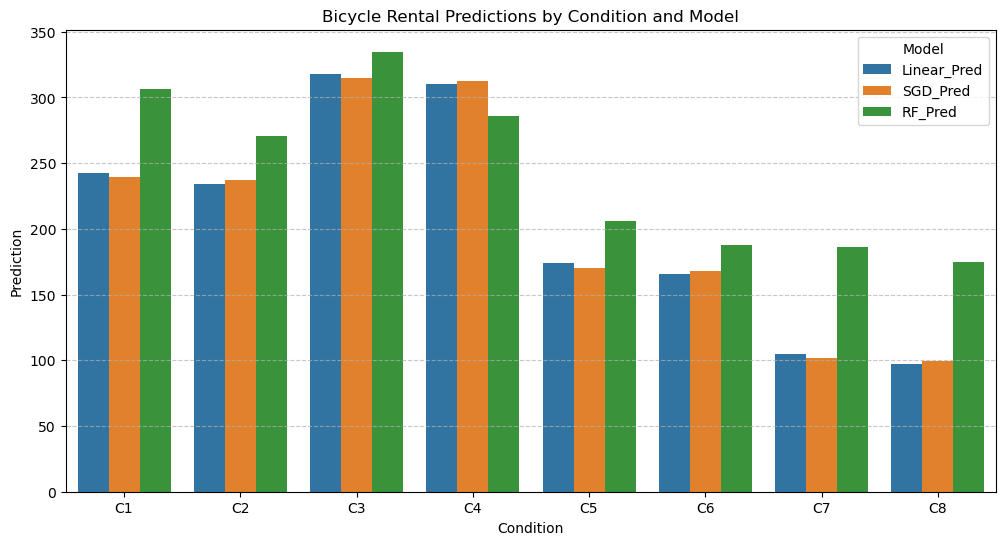

In [101]:
# 모델별 예측 경향 비교를 위한 그래프 
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 재구성 (시각화를 위해 긴 형태로 변환)
df_melted = results.melt(id_vars=['Condition', 'Temp', 'Is_Holiday'], 
                         value_vars=['Linear_Pred', 'SGD_Pred', 'RF_Pred'],
                         var_name='Model', value_name='Prediction')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Condition', y='Prediction', hue='Model')
plt.title('Bicycle Rental Predictions by Condition and Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# 날씨가 가장 더운 C3 C4에서 자전거 타는사람이 가장 많은걸 알수있습니다.
# 그리고 위의 분포도에서도 봤듯 집중해서 분포되지않은(대여량이적은) C7 C8 조건에서 오차가 커집니다
# 위에있는 온도습도에 따른 시각화 자료에서 오차가많은부분에서 정답(회색) 있는곳엔 RF모델예측(녹색) 밖에 없었던걸
# 생각해보면 여기서도 녹색이 정확도가 높을것으로 간주하고 보는게 좋을것 같습니다.

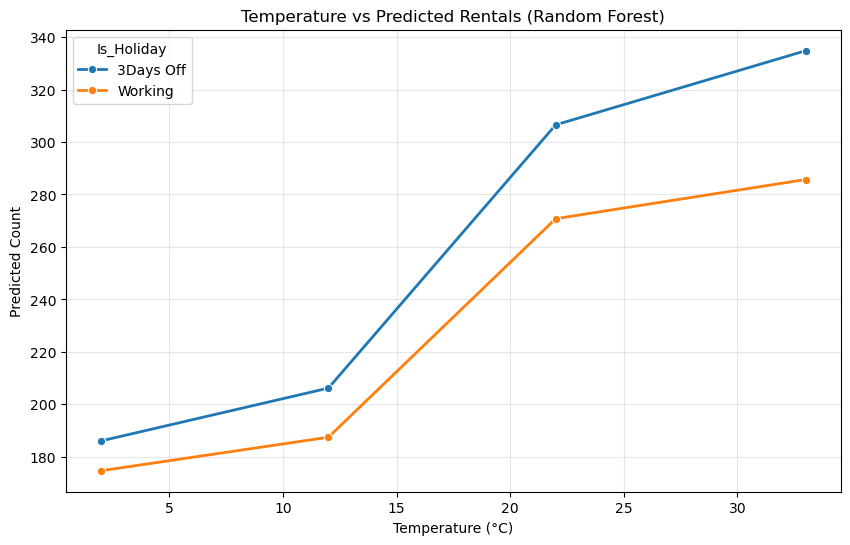

In [102]:
# 온도에따른 대여량 변화 추이 라인그래프
plt.figure(figsize=(10, 6))

# RF 모델을 기준으로 휴일/평일 비교 시각화
sns.lineplot(data=results, x='Temp', y='RF_Pred', hue='Is_Holiday', marker='o', linewidth=2)

plt.title('Temperature vs Predicted Rentals (Random Forest)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Predicted Count')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 여기서도 재밌는 부분이 있는데 3일 연속 휴일에 포함된 월요일이라는 이유보다는
# 온도 즉 맑은 날씨중에서도 온도가 높은 따듯한날 더 자전거를 많이 타는것을 알수있습니다.

In [103]:
# 질문에 대한 답은 끝났지만 반대로 같은경우에, 날씨가 안좋은경우는 어떤지도 궁금하지않나요?
# 먼저 날씨의 값이 어떻게 되있는지 보면
train['weather'].value_counts()



weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64

In [108]:
# AI에게 물어보니
# 1은 맑음 혹은 구름이 조금있는정도
# 2는 안개 혹은 흐림
# 3은 가벼운 눈/비 혹은 뇌우
# 4는 폭우 폭설 허리케인급

# 개인적으로는 조금 안개가 있다고 자전거를 타는사람이 크게 줄진 않을거같아요
# 날씨를 3으로 수정해보죠

# 1. 기본 베이스 데이터 설정 (화창한 월요일 오후 3시) 
# features1에있던 11개 데이터를 명시
base_data = {
    'month': 5, 'hour': 15, 'holiday': 0, 'workingday': 1, 
    'weather': 3, 'temp': 22.0, 'humidity': 70, 'windspeed': 20.0, 
    'weekday': 0, 'weekend': 0, 'consecutive_nowork_days': 0
}

# 2. 8가지 조건을 담을 리스트
test_list = []

# (온도 22도 고정) condition 2개
c1 = base_data.copy()
c1.update({'workingday': 0, 'holiday': 1, 'consecutive_nowork_days': 3})
test_list.append(c1)

c2 = base_data.copy()
test_list.append(c2)

# 더운 월요일 (온도 33도로 수정) condition 2개
c3 = base_data.copy()
c3.update({'workingday': 0, 'holiday': 1, 'consecutive_nowork_days': 3, 'temp': 33})
test_list.append(c3)

c4 = base_data.copy()
c4.update({'temp': 33})
test_list.append(c4)

# 선선한 월요일 (온도 12도로 수정) condition 2개
c5 = base_data.copy()
c5.update({'workingday': 0, 'holiday': 1, 'consecutive_nowork_days': 3, 'temp': 12})
test_list.append(c5)

c6 = base_data.copy()
c6.update({'temp': 12})
test_list.append(c6)

# 개추운 월요일 (온도 2도로 수정) condition 2개
c7 = base_data.copy()
c7.update({'workingday': 0, 'holiday': 1, 'consecutive_nowork_days': 3, 'temp': 2})
test_list.append(c7)

c8 = base_data.copy()
c8.update({'temp': 2})
test_list.append(c8)

test_custom = pd.DataFrame(test_list)

# 3. 원-핫 인코딩 적용 
# 학습 데이터에 사용된 인코딩된 컬럼 리스트를 가져옵니다.
train_cols = X_train.columns 

# 테스트 데이터 인코딩 후, 학습 데이터 컬럼 기준으로 재정렬 (없는 컬럼은 0으로 채움)
test_custom_encoded = pd.get_dummies(test_custom).reindex(columns=train_cols, fill_value=0)

In [109]:
# [custom_test] 이제 테스트 데이터셋을 적용해 보겠습니다.

# 방금새로만든 데이터는 standardization이 필요하고 그 값으로 X_test변수를 대체해주면됩니다.


# from sklearn.preprocessing import StandardScaler # 위에서해줌
# scaler = StandardScaler() 이것도 위에서 해준거 그대로 재사용해야함 
# (scaler가 fit할때 평균 표준편차등 정보를 기억하고있음)
test_custom_encoded_scaled = scaler.transform(test_custom_encoded)


# 1, 선형회귀법
model_linear = LinearRegression()
model_linear.fit(X_train_scaled, y_train)
y_pred_linear = model_linear.predict(test_custom_encoded_scaled)

# 2. 경사하강법 사용, 단위가 바뀌지않았으니 아까 사용했던 데이터중 가장 오차가 적었던것을 재사용
model_sgd = SGDRegressor(max_iter=1000, eta0=0.001, learning_rate='invscaling', random_state=42)
model_sgd.fit(X_train_scaled, y_train)
y_pred_sgd = model_sgd.predict(test_custom_encoded_scaled)


# 3. from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train_scaled, y_train)
y_pred_rf = model_rf.predict(test_custom_encoded_scaled)


y_pred_linear = np.maximum(0, y_pred_linear)
y_pred_sgd = np.maximum(0, y_pred_sgd)


# --- 결과를 표 형태로 예쁘게 출력하기 ---
results = pd.DataFrame({
    'Condition': [f'C{i+1}' for i in range(8)],
    'Temp': [22, 22, 33, 33, 12, 12, 2, 2],
    'Is_Holiday': ['3Days Off', 'Working', '3Days Off', 'Working', '3Days Off', 'Working', '3Days Off', 'Working'],
    'Linear_Pred': y_pred_linear,
    'SGD_Pred': y_pred_sgd,
    'RF_Pred': y_pred_rf
})

print("--- [8가지 조건별 자전거 대여량 예측 결과] ---")
print(results.to_string(index=False))



--- [8가지 조건별 자전거 대여량 예측 결과] ---
Condition  Temp Is_Holiday  Linear_Pred   SGD_Pred  RF_Pred
       C1    22  3Days Off   200.509293 197.294778   290.58
       C2    22    Working   192.391227 194.969306   243.45
       C3    33  3Days Off   276.100262 273.048396   317.69
       C4    33    Working   267.982195 270.722923   263.60
       C5    12  3Days Off   131.790232 128.427853   209.33
       C6    12    Working   123.672165 126.102380   163.69
       C7     2  3Days Off    63.071170  59.560928   192.77
       C8     2    Working    54.953103  57.235455   154.84


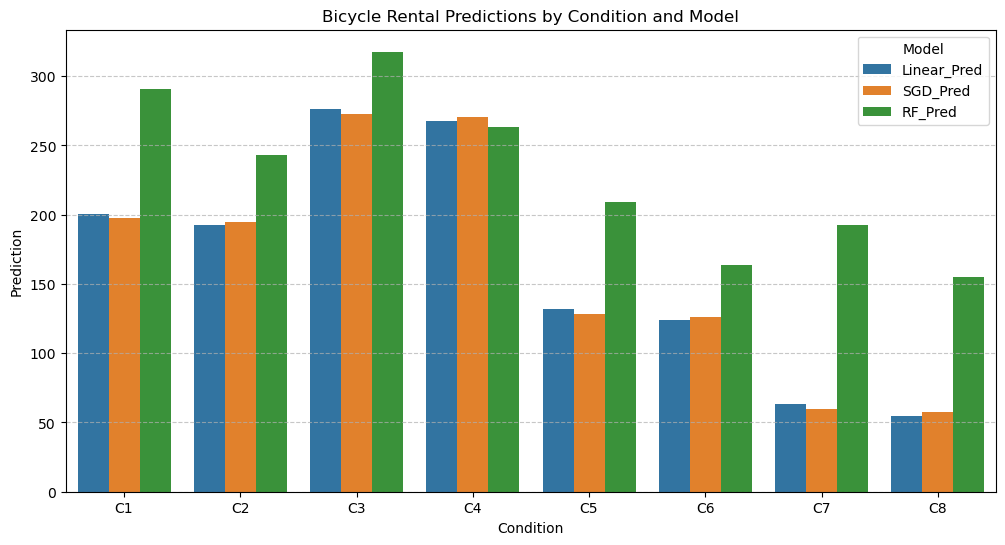

In [110]:
# 모델별 예측 경향 비교를 위한 그래프 
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 재구성 (시각화를 위해 긴 형태로 변환)
df_melted = results.melt(id_vars=['Condition', 'Temp', 'Is_Holiday'], 
                         value_vars=['Linear_Pred', 'SGD_Pred', 'RF_Pred'],
                         var_name='Model', value_name='Prediction')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Condition', y='Prediction', hue='Model')
plt.title('Bicycle Rental Predictions by Condition and Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

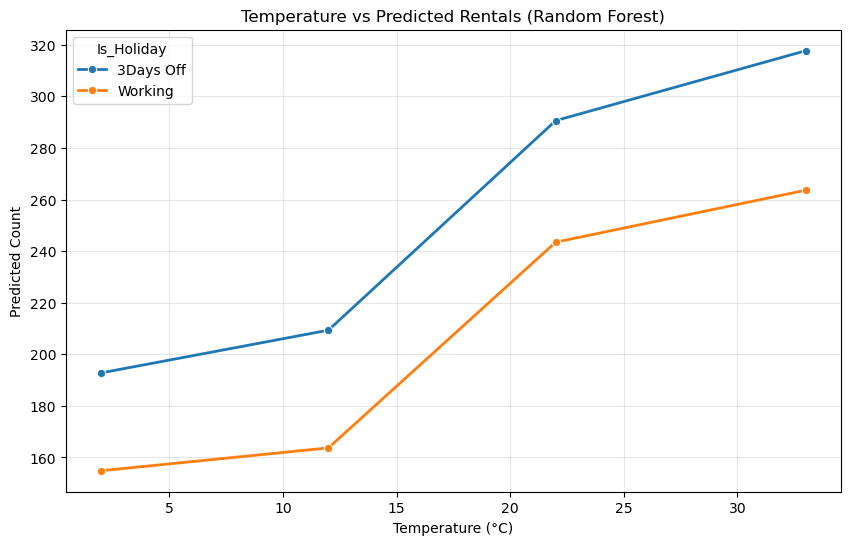

In [111]:
# 온도에따른 대여량 변화 추이 라인그래프
plt.figure(figsize=(10, 6))

# RF 모델을 기준으로 휴일/평일 비교 시각화
sns.lineplot(data=results, x='Temp', y='RF_Pred', hue='Is_Holiday', marker='o', linewidth=2)

plt.title('Temperature vs Predicted Rentals (Random Forest)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Predicted Count')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 먼저 weather 만 3으로 바꿨을때는 결과값이 weather가 1일때랑 완벽히 같았습니다.
# 원핫인코딩때문인지 weather 1,2,3,4 값이 있는데 결과에 영향이 없었습니다.
# 그래서 풍속을 10 > 20 으로 습도를 50 > 70 으로 늘려줬더니 경우에따라 약 5~9%씩 
# 대여량이 줄어든걸 알수 있었습니다.
# weather 값같은경우는 원핫인코딩을 하는것보다 숫자의크기가 의미하는것이 있으니 standardization을 하는것이
# 좋다고 생각됩니다. 하지만 실험은 여기까지. 하려다가 확인하고싶어짐.

In [114]:
#위에 있는 코드를 복사 붙여넣기해서 주석에 중복이 있는점 양해바랍니다

# 변수명은 그냥 뒤에 1,2,3,4 숫자를 붙일게요 너무 길어지니까.
features1 = ['month', 'hour', 'holiday', 'workingday', 'weather', 'temp', 'humidity', 'windspeed', 'weekday', 'weekend', 'consecutive_nowork_days']
features2 = ['month', 'hour', 'weather', 'temp', 'humidity', 'windspeed', 'consecutive_nowork_days']
features3 = ['month', 'hour', 'holiday', 'workingday', 'weekday', 'weekend', 'consecutive_nowork_days']
features4 = ['hour', 'consecutive_nowork_days']

X = train[features1]
y = train['count']

# padas로 원핫인코딩
# consecutive_nowork_days 를 원핫인코딩을 할때랑 안할때랑 다를것같지만 너무 테스트데이터가 많아지니까 제외
# 아래에서 standardizatin만 해줄게요

# ***** 여기서 weather 제외*****************
X_encoded = pd.get_dummies(X, columns=['holiday', 'workingday', 'weekday', 'weekend'])

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# 3. Standardization 표준화 
# from sklearn.preprocessing import OneHotEncoder, StandardScaler # 위에서 했음

scaler = StandardScaler()

# 학습데이터 변환 - 학습후 변환하는 fit_transfrom 함수사용
X_train_scaled = scaler.fit_transform(X_train)
#예측용 테스트데이터 변환
X_test_scaled = scaler.transform(X_test)

print("정규화 완료된 데이터 샘플:\n", X_train_scaled[0])

정규화 완료된 데이터 샘플:
 [ 0.13822447 -0.94596221 -0.65728558  0.97726179  1.09855333 -0.82835619
 -0.65874393  0.17333479 -0.17333479 -0.68444534  0.68444534 -0.4044118
 -0.40652381  2.4575622  -0.40939621 -0.40709899 -0.41226005 -0.41111553
  0.63886623 -0.63886623]


In [115]:
# [Feature1] 가장 성능이 좋았던 Feature1 재훈련

# 1, 선형회귀법
model_linear = LinearRegression()
model_linear.fit(X_train_scaled, y_train)

y_pred_linear = model_linear.predict(X_test_scaled)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
print(f"[Linear] MSE: {mse_linear}, RMSE: {rmse_linear}")

# 2. 경사하강법 사용, 단위가 바뀌지않았으니 아까 사용했던 데이터중 가장 오차가 적었던것을 재사용
model_sgd = SGDRegressor(max_iter=1000, eta0=0.001, learning_rate='invscaling', random_state=42)
model_sgd.fit(X_train_scaled, y_train)

y_pred_sgd = model_sgd.predict(X_test_scaled)
mse_sgd = mean_squared_error(y_test, y_pred_sgd)
rmse_sgd = np.sqrt(mse_sgd)

print(f"[SGD] MSE: {mse_sgd}, RMSE: {rmse_sgd}")


# 3. from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train_scaled, y_train)

y_pred_rf = model_rf.predict(X_test_scaled)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print(f"[RF] MSE: {mse_rf}, RMSE: {rmse_rf}")



[Linear] MSE: 21679.22370078698, RMSE: 147.23866238453465
[SGD] MSE: 21685.533741166724, RMSE: 147.26008875851844
[RF] MSE: 4410.025248953704, RMSE: 66.40802096850729


In [116]:
# 146 146 66 이었는데 일단 현재데이터로는 거의같은성능으로 보입니다.

In [117]:
# 다시 좋은날씨 데이터를 가져옵니다
# 1. 기본 베이스 데이터 설정 (화창한 월요일 오후 3시) 
# features1에있던 11개 데이터를 명시
base_data = {
    'month': 5, 'hour': 15, 'holiday': 0, 'workingday': 1, 
    'weather': 1, 'temp': 22.0, 'humidity': 50, 'windspeed': 10.0, 
    'weekday': 0, 'weekend': 0, 'consecutive_nowork_days': 0
}

# 2. 8가지 조건을 담을 리스트
test_list = []

# (온도 22도 고정) condition 2개
c1 = base_data.copy()
c1.update({'workingday': 0, 'holiday': 1, 'consecutive_nowork_days': 3})
test_list.append(c1)

c2 = base_data.copy()
test_list.append(c2)

# 더운 월요일 (온도 33도로 수정) condition 2개
c3 = base_data.copy()
c3.update({'workingday': 0, 'holiday': 1, 'consecutive_nowork_days': 3, 'temp': 33})
test_list.append(c3)

c4 = base_data.copy()
c4.update({'temp': 33})
test_list.append(c4)

# 선선한 월요일 (온도 12도로 수정) condition 2개
c5 = base_data.copy()
c5.update({'workingday': 0, 'holiday': 1, 'consecutive_nowork_days': 3, 'temp': 12})
test_list.append(c5)

c6 = base_data.copy()
c6.update({'temp': 12})
test_list.append(c6)

# 개추운 월요일 (온도 2도로 수정) condition 2개
c7 = base_data.copy()
c7.update({'workingday': 0, 'holiday': 1, 'consecutive_nowork_days': 3, 'temp': 2})
test_list.append(c7)

c8 = base_data.copy()
c8.update({'temp': 2})
test_list.append(c8)

test_custom = pd.DataFrame(test_list)

# 3. 원-핫 인코딩 적용 
# 학습 데이터에 사용된 인코딩된 컬럼 리스트를 가져옵니다.
train_cols = X_train.columns 

# 테스트 데이터 인코딩 후, 학습 데이터 컬럼 기준으로 재정렬 (없는 컬럼은 0으로 채움)
test_custom_encoded = pd.get_dummies(test_custom).reindex(columns=train_cols, fill_value=0)

In [118]:
# [custom_test] 이제 테스트 데이터셋을 적용해 보겠습니다.

# 방금새로만든 데이터는 standardization이 필요하고 그 값으로 X_test변수를 대체해주면됩니다.


# from sklearn.preprocessing import StandardScaler # 위에서해줌
# scaler = StandardScaler() 이것도 위에서 해준거 그대로 재사용해야함 
# (scaler가 fit할때 평균 표준편차등 정보를 기억하고있음)
test_custom_encoded_scaled = scaler.transform(test_custom_encoded)


# 1, 선형회귀법
model_linear = LinearRegression()
model_linear.fit(X_train_scaled, y_train)
y_pred_linear = model_linear.predict(test_custom_encoded_scaled)

# 2. 경사하강법 사용, 단위가 바뀌지않았으니 아까 사용했던 데이터중 가장 오차가 적었던것을 재사용
model_sgd = SGDRegressor(max_iter=1000, eta0=0.001, learning_rate='invscaling', random_state=42)
model_sgd.fit(X_train_scaled, y_train)
y_pred_sgd = model_sgd.predict(test_custom_encoded_scaled)


# 3. from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train_scaled, y_train)
y_pred_rf = model_rf.predict(test_custom_encoded_scaled)


y_pred_linear = np.maximum(0, y_pred_linear)
y_pred_sgd = np.maximum(0, y_pred_sgd)


# --- 결과를 표 형태로 예쁘게 출력하기 ---
results = pd.DataFrame({
    'Condition': [f'C{i+1}' for i in range(8)],
    'Temp': [22, 22, 33, 33, 12, 12, 2, 2],
    'Is_Holiday': ['3Days Off', 'Working', '3Days Off', 'Working', '3Days Off', 'Working', '3Days Off', 'Working'],
    'Linear_Pred': y_pred_linear,
    'SGD_Pred': y_pred_sgd,
    'RF_Pred': y_pred_rf
})

print("--- [8가지 조건별 자전거 대여량 예측 결과] ---")
print(results.to_string(index=False))



--- [8가지 조건별 자전거 대여량 예측 결과] ---
Condition  Temp Is_Holiday  Linear_Pred   SGD_Pred  RF_Pred
       C1    22  3Days Off   243.790903 241.165190   319.42
       C2    22    Working   237.460356 239.395953   282.20
       C3    33  3Days Off   319.122279 316.658882   356.98
       C4    33    Working   312.791732 314.889645   284.96
       C5    12  3Days Off   175.307834 172.534561   216.71
       C6    12    Working   168.977287 170.765324   195.86
       C7     2  3Days Off   106.824765 103.903932   192.52
       C8     2    Working   100.494218 102.134695   180.87


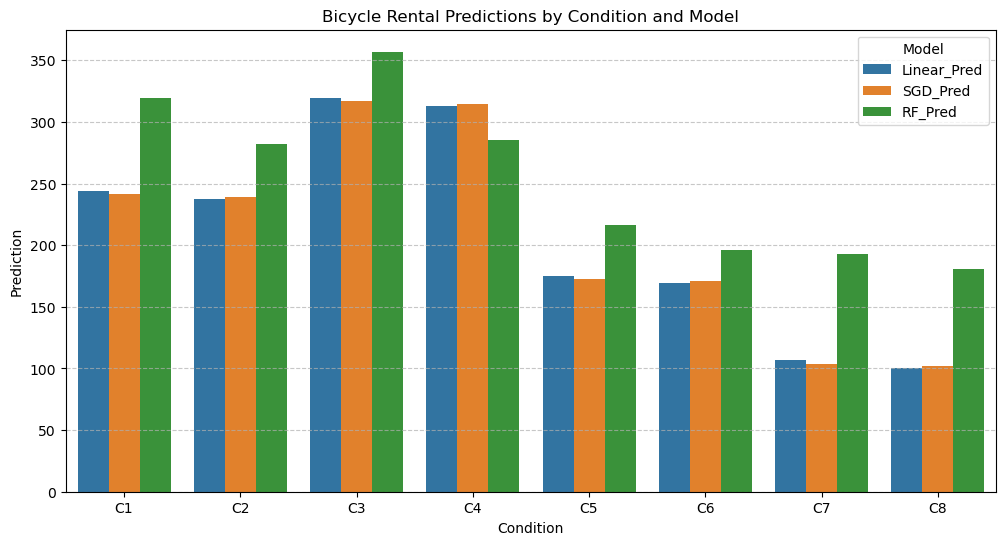

In [119]:
# 그래프도 똑같이 그려줍니다. 안좋은날씨랑 비교를 해야하니까요.
# 모델별 예측 경향 비교를 위한 그래프 
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 재구성 (시각화를 위해 긴 형태로 변환)
df_melted = results.melt(id_vars=['Condition', 'Temp', 'Is_Holiday'], 
                         value_vars=['Linear_Pred', 'SGD_Pred', 'RF_Pred'],
                         var_name='Model', value_name='Prediction')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Condition', y='Prediction', hue='Model')
plt.title('Bicycle Rental Predictions by Condition and Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

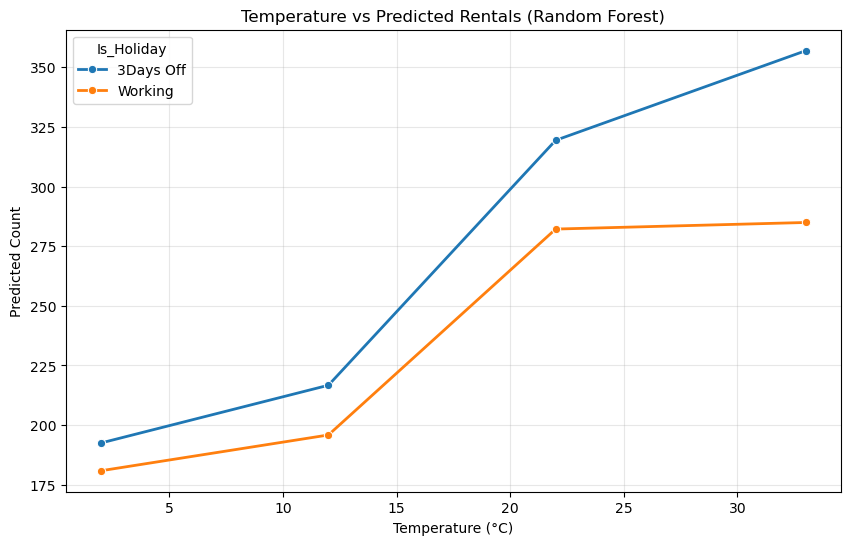

In [120]:
# 온도에따른 대여량 변화 추이 라인그래프
plt.figure(figsize=(10, 6))

# RF 모델을 기준으로 휴일/평일 비교 시각화
sns.lineplot(data=results, x='Temp', y='RF_Pred', hue='Is_Holiday', marker='o', linewidth=2)

plt.title('Temperature vs Predicted Rentals (Random Forest)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Predicted Count')
plt.grid(True, alpha=0.3)
plt.show()

In [121]:
# 안좋은 날씨
# AI에게 물어보니
# 1은 맑음 혹은 구름이 조금있는정도
# 2는 안개 혹은 흐림
# 3은 가벼운 눈/비 혹은 뇌우
# 4는 폭우 폭설 허리케인급

# 개인적으로는 조금 안개가 있다고 자전거를 타는사람이 크게 줄진 않을거같아요
# 날씨를 3으로 수정해보죠

# 1. 기본 베이스 데이터 설정 (화창한 월요일 오후 3시) 
# features1에있던 11개 데이터를 명시
base_data = {
    'month': 5, 'hour': 15, 'holiday': 0, 'workingday': 1, 
    'weather': 3, 'temp': 22.0, 'humidity': 70, 'windspeed': 20.0, 
    'weekday': 0, 'weekend': 0, 'consecutive_nowork_days': 0
}

# 2. 8가지 조건을 담을 리스트
test_list = []

# (온도 22도 고정) condition 2개
c1 = base_data.copy()
c1.update({'workingday': 0, 'holiday': 1, 'consecutive_nowork_days': 3})
test_list.append(c1)

c2 = base_data.copy()
test_list.append(c2)

# 더운 월요일 (온도 33도로 수정) condition 2개
c3 = base_data.copy()
c3.update({'workingday': 0, 'holiday': 1, 'consecutive_nowork_days': 3, 'temp': 33})
test_list.append(c3)

c4 = base_data.copy()
c4.update({'temp': 33})
test_list.append(c4)

# 선선한 월요일 (온도 12도로 수정) condition 2개
c5 = base_data.copy()
c5.update({'workingday': 0, 'holiday': 1, 'consecutive_nowork_days': 3, 'temp': 12})
test_list.append(c5)

c6 = base_data.copy()
c6.update({'temp': 12})
test_list.append(c6)

# 개추운 월요일 (온도 2도로 수정) condition 2개
c7 = base_data.copy()
c7.update({'workingday': 0, 'holiday': 1, 'consecutive_nowork_days': 3, 'temp': 2})
test_list.append(c7)

c8 = base_data.copy()
c8.update({'temp': 2})
test_list.append(c8)

test_custom = pd.DataFrame(test_list)

# 3. 원-핫 인코딩 적용 
# 학습 데이터에 사용된 인코딩된 컬럼 리스트를 가져옵니다.
train_cols = X_train.columns 

# 테스트 데이터 인코딩 후, 학습 데이터 컬럼 기준으로 재정렬 (없는 컬럼은 0으로 채움)
test_custom_encoded = pd.get_dummies(test_custom).reindex(columns=train_cols, fill_value=0)

In [122]:
# [custom_test] 이제 테스트 데이터셋을 적용해 보겠습니다.

# 방금새로만든 데이터는 standardization이 필요하고 그 값으로 X_test변수를 대체해주면됩니다.


# from sklearn.preprocessing import StandardScaler # 위에서해줌
# scaler = StandardScaler() 이것도 위에서 해준거 그대로 재사용해야함 
# (scaler가 fit할때 평균 표준편차등 정보를 기억하고있음)
test_custom_encoded_scaled = scaler.transform(test_custom_encoded)


# 1, 선형회귀법
model_linear = LinearRegression()
model_linear.fit(X_train_scaled, y_train)
y_pred_linear = model_linear.predict(test_custom_encoded_scaled)

# 2. 경사하강법 사용, 단위가 바뀌지않았으니 아까 사용했던 데이터중 가장 오차가 적었던것을 재사용
model_sgd = SGDRegressor(max_iter=1000, eta0=0.001, learning_rate='invscaling', random_state=42)
model_sgd.fit(X_train_scaled, y_train)
y_pred_sgd = model_sgd.predict(test_custom_encoded_scaled)


# 3. from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train_scaled, y_train)
y_pred_rf = model_rf.predict(test_custom_encoded_scaled)


y_pred_linear = np.maximum(0, y_pred_linear)
y_pred_sgd = np.maximum(0, y_pred_sgd)


# --- 결과를 표 형태로 예쁘게 출력하기 ---
results = pd.DataFrame({
    'Condition': [f'C{i+1}' for i in range(8)],
    'Temp': [22, 22, 33, 33, 12, 12, 2, 2],
    'Is_Holiday': ['3Days Off', 'Working', '3Days Off', 'Working', '3Days Off', 'Working', '3Days Off', 'Working'],
    'Linear_Pred': y_pred_linear,
    'SGD_Pred': y_pred_sgd,
    'RF_Pred': y_pred_rf
})

print("--- [8가지 조건별 자전거 대여량 예측 결과] ---")
print(results.to_string(index=False))



--- [8가지 조건별 자전거 대여량 예측 결과] ---
Condition  Temp Is_Holiday  Linear_Pred   SGD_Pred  RF_Pred
       C1    22  3Days Off   193.789299 190.803154   252.13
       C2    22    Working   187.458752 189.033917   199.78
       C3    33  3Days Off   269.120675 266.296846   324.99
       C4    33    Working   262.790128 264.527609   244.87
       C5    12  3Days Off   125.306229 122.172525   178.92
       C6    12    Working   118.975683 120.403288   173.71
       C7     2  3Days Off    56.823160  53.541896   174.86
       C8     2    Working    50.492613  51.772659   163.89


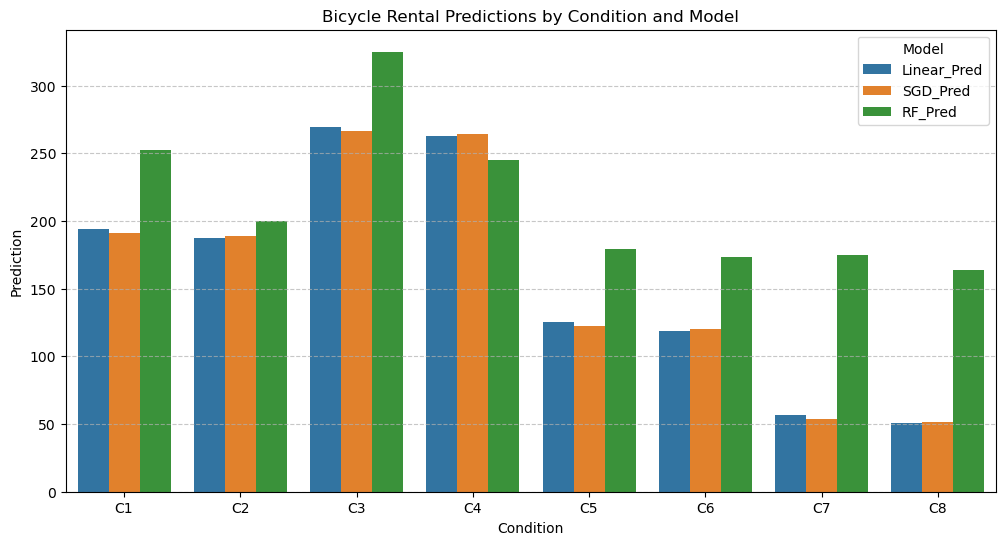

In [123]:
# 그래프도 똑같이 그려줍니다. 안좋은날씨랑 비교를 해야하니까요.
# 모델별 예측 경향 비교를 위한 그래프 
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 재구성 (시각화를 위해 긴 형태로 변환)
df_melted = results.melt(id_vars=['Condition', 'Temp', 'Is_Holiday'], 
                         value_vars=['Linear_Pred', 'SGD_Pred', 'RF_Pred'],
                         var_name='Model', value_name='Prediction')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Condition', y='Prediction', hue='Model')
plt.title('Bicycle Rental Predictions by Condition and Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

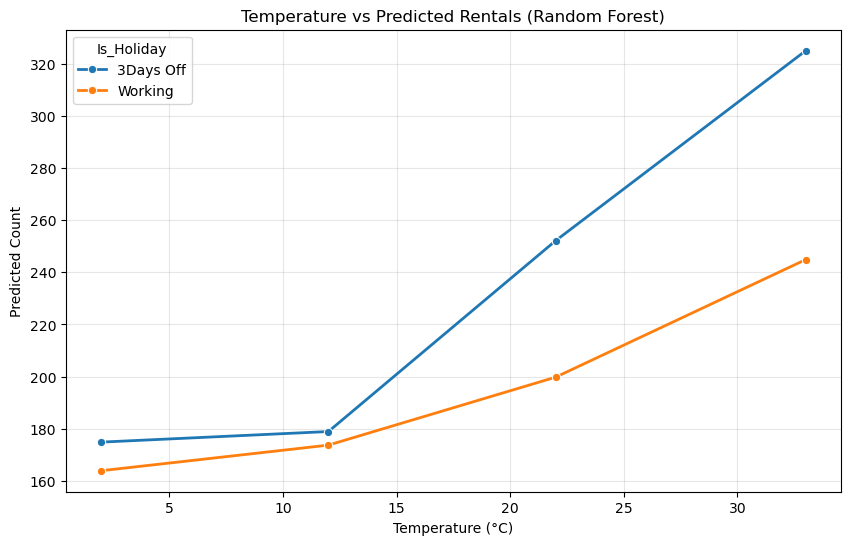

In [124]:
# 온도에따른 대여량 변화 추이 라인그래프
plt.figure(figsize=(10, 6))

# RF 모델을 기준으로 휴일/평일 비교 시각화
sns.lineplot(data=results, x='Temp', y='RF_Pred', hue='Is_Holiday', marker='o', linewidth=2)

plt.title('Temperature vs Predicted Rentals (Random Forest)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Predicted Count')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# weather를 one-hot-encoding 한 경우
# --- [8가지 조건별 자전거 대여량 예측 결과] ---
# Condition  Temp Is_Holiday  Linear_Pred   SGD_Pred  RF_Pred
#        C1    22  3Days Off   242.507514 239.236250   306.55
#        C2    22    Working   234.389447 236.910778   270.77
#        C3    33  3Days Off   318.098482 314.989868   334.81
#        C4    33    Working   309.980415 312.664396   285.70
#        C5    12  3Days Off   173.788452 170.369325   206.18
#        C6    12    Working   165.670385 168.043852   187.44
#        C7     2  3Days Off   105.069390 101.502400   186.05
#        C8     2    Working    96.951323  99.176927   174.68

# 날씨 안좋음  ------------------------------------- 좋은 날씨 대비 약 10% 줄어듬
# --- [8가지 조건별 자전거 대여량 예측 결과] ---
# Condition  Temp Is_Holiday  Linear_Pred   SGD_Pred  RF_Pred
#        C1    22  3Days Off   200.509293 197.294778   290.58
#        C2    22    Working   192.391227 194.969306   243.45
#        C3    33  3Days Off   276.100262 273.048396   317.69
#        C4    33    Working   267.982195 270.722923   263.60
#        C5    12  3Days Off   131.790232 128.427853   209.33
#        C6    12    Working   123.672165 126.102380   163.69
#        C7     2  3Days Off    63.071170  59.560928   192.77
#        C8     2    Working    54.953103  57.235455   154.84

# weather를 standardization 한 경우
# 날씨 좋음
# --- [8가지 조건별 자전거 대여량 예측 결과] ---
# Condition  Temp Is_Holiday  Linear_Pred   SGD_Pred  RF_Pred
#        C1    22  3Days Off   243.790903 241.165190   319.42
#        C2    22    Working   237.460356 239.395953   282.20
#        C3    33  3Days Off   319.122279 316.658882   356.98
#        C4    33    Working   312.791732 314.889645   284.96
#        C5    12  3Days Off   175.307834 172.534561   216.71
#        C6    12    Working   168.977287 170.765324   195.86
#        C7     2  3Days Off   106.824765 103.903932   192.52
#        C8     2    Working   100.494218 102.134695   180.87

# 날씨 안좋음    ------------------------------------------ 좋은 날씨 대비 약 15% 줄어듬 (9~29%)
# --- [8가지 조건별 자전거 대여량 예측 결과] ---
# Condition  Temp Is_Holiday  Linear_Pred   SGD_Pred  RF_Pred
#        C1    22  3Days Off   193.789299 190.803154   252.13
#        C2    22    Working   187.458752 189.033917   199.78
#        C3    33  3Days Off   269.120675 266.296846   324.99
#        C4    33    Working   262.790128 264.527609   244.87
#        C5    12  3Days Off   125.306229 122.172525   178.92
#        C6    12    Working   118.975683 120.403288   173.71
#        C7     2  3Days Off    56.823160  53.541896   174.86
#        C8     2    Working    50.492613  51.772659   163.89

In [127]:
# RMSE수치는 똑같이 66이지만, 제 예상이 맞았습니다
# Weather같이 숫자의 크기에 의미가있는경우 단순히 범주로 여기는게 안좋은 판단이 될수도있다는겁니다.
# 강의자료에서 봤듯이 원핫인코딩은 숫자의 크기의를 단순히 분리만해주지 뭐가 더 세고 약하고의 개념을 없애버립니다.

# 위 그래프만 비교해봐도 한눈에 알수있는데
# weather값을 원핫인코딩했을때는 weather 데이터가 전혀 반영되지 않았습니다 (현재 데이터, 기준)
# 하지만 weather값을 standardization해주니 확실히 값을 반영하는것을 볼수 있었습니다.

# 그래도 여전히 뭐가 정답인지 우리는 모릅니다.
# 실제데이터 오차를 (RMSE값) 확인했을때는 둘다 66이었으니까요.
# 워싱턴 DC 도시사람들은 비가와도 눈이와도 따뜻하고 바람이약하면 자전거 탈수도 있잖아요 ^^;